## **Setup & Visualization Style**

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import roc_auc_score, precision_recall_curve, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, VotingClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
import shap
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.utils import concordance_index

from scipy.stats import mannwhitneyu, pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score

import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="white")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
PALETTE = {
    'base':   '#D8DEE4',
    'accent': '#1F7A6C', 
    'accent2':'#E27D60', 
    'text':   '#2B2D42',
    'grid':   '#E5E7EB',
}

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.edgecolor': PALETTE['grid'],
    'axes.labelcolor': PALETTE['text'],
    'text.color': PALETTE['text'],
    'xtick.color': PALETTE['text'],
    'ytick.color': PALETTE['text'],
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
})

def style_ax(ax, grid_axis=None):
    """Helper minimalis: buang spine yang tidak perlu + grid tipis di belakang bar."""
    sns.despine(ax=ax, left=(grid_axis == 'y'), bottom=(grid_axis == 'x'))
    if grid_axis == 'y':
        ax.yaxis.grid(True, color=PALETTE['grid'], linewidth=0.8, zorder=0)
        ax.set_axisbelow(True)
    elif grid_axis == 'x':
        ax.xaxis.grid(True, color=PALETTE['grid'], linewidth=0.8, zorder=0)
        ax.set_axisbelow(True)


In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/micelll/SPARC-2026/main/SPARC_dataset.csv", low_memory=False)

## **Problem Framing**

**Objektif**

Memprediksi probabilitas pelanggan melakukan Repeat Order

**Definisi target**

Label 1 (Repeat Order / Target Positif) adalah pelanggan yang tercatat melakukan minimal 2 kali transaksi pembelian motor pada tanggal yang berbeda. Customer menunjukkan niat untuk kembali setelah selang waktu tertentu (profil pelanggan ideal yang perilakunya ingin dipelajari oleh model ML untuk di-follow-up di masa depan)

Label 0 (One-Time Buyer / Target Negatif) adalah Pelanggan yang hanya memiliki riwayat transaksi pada 1 tanggal spesifik saja dan tidak pernah kembali lagi di hari-hari berikutnya.

## **Data Preprocessing and Cleaning**

**Drop column dengan mayoritas Missing values**

In [4]:
df = df.drop(columns=['tgl cetak', 'DLR group', 'Agama'], errors='ignore')
df = df.drop_duplicates()

df = df.dropna(subset=['Customer ID'])

Ditemukan baris data yang benar-benar duplikat (identik di seluruh kolom, bukan sekadar customer yang sama). Baris ini kemungkinan hasil double-input/double-export saat penggabungan data. Karena proses feature engineering nanti menjumlahkan OTR, DP, dan cicilan per pelanggan, baris kembar ini akan menggandakan nilai finansial pelanggan yang terdampak jadi harus dibuang di awal, sebelum data diproses lebih jauh.

**Data Demografi**

In [5]:
# split provisinsi dengan kota
if 'Kode Kota-Provinsi' in df.columns:
    split_cols = df['Kode Kota-Provinsi'].astype(str).str.split(r'[-,\/]', n=1, expand=True)
    if split_cols.shape[1] == 2:
        df['Kota'] = split_cols[0].str.strip()
        df['Provinsi'] = split_cols[1].str.strip()
    df = df.drop(columns=['Kode Kota-Provinsi'])

data lokasi yang tergabung dengan berbagai macam format simbol pemisah (seperti strip, koma, atau garis miring) sangat sulit dipahami oleh model machine learning, sehingga datanya perlu dipisah dan dibersihkan

In [6]:
# replace dummy di setiap variable menjadi NULL
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].replace(['N', 'n', 'NAN', 'nan'], np.nan)

terdapat data kosong yang tersimpan bukan sebagai benar-benar null, melainkan mengisinya dengan teks dummy. jadi kami memindai semua categorical dan ariasi tulisan yang mengindikasikan kekosongan menjadi format missing value

In [7]:
# Kode Dealer dari float jadi object (kategorikal data)
if 'Kode Dealer' in df.columns:
    df['Kode Dealer'] = df['Kode Dealer'].astype(str).str.replace(r'\.0$', '', regex=True)

dealer adalah label identitas (kategori), bukan angka matematis. Jika dibiarkan berformat angka, model akan keliru menganggap kode tersebut memiliki besaran nilai atau tingkatan yang bisa dihitung.

**Standarisasi format pada data string**

In [8]:
# Standarisasi Teks (String Cleansing)
cat_cols = ['Kelurahan', 'Kecamatan', 'warna', 'Pekerjaan', 'type series', 'range dp', 'Kode POS', 'wilayah']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower().str.strip()

Mencegah model menganggap data yang sama sebagai kategori berbeda hanya karena perbedaan huruf besar/kecil atau tambahan spasi

In [9]:
# standarisasi kategori range DP
range_dp_map = {
    'kurang 1 juta': '< 1 juta', 'krg 1 jt': '< 1 juta', 'krg 1 juta': '< 1 juta', 'kurang 1 jt': '< 1 juta',
    '1 - 2 jt': '1 - 2 juta',
    '2 - 3 jt': '2 - 3 juta',
    '3 jt up': '> 3 juta', '3 juta up': '> 3 juta'
}
if 'range dp' in df.columns:
    df['range dp'] = df['range dp'].replace(range_dp_map)

Standarisasi format pada variable range_dp, hasilnya jadi 4 range

**Pembersihan Tipe Data Numerik**

In [10]:
# Regex & Parsing Nilai Finansial
def clean_currency(x):
    if pd.isna(x) or str(x).lower() == 'nan': return np.nan
    # Hapus 'rp', titik, koma, dan spasi
    x_str = str(x).lower().replace('rp', '').replace('.', '').replace(' ', '').replace(',', '')
    nums = re.findall(r'\d+', x_str)
    if nums: return float(''.join(nums))
    return 0.0

df['dp aktual'] = df['dp aktual'].apply(clean_currency)
df['cicilan'] = df['cicilan'].apply(clean_currency)
df['OTR'] = pd.to_numeric(df['OTR'], errors='coerce')

Membersihkan kolom finansial ('dp aktual', 'cicilan', dan 'OTR') dari format teks untuk mengubahnya menjadi angka karena bentuk asli dari column ini adalah representasi angka bukan string

In [11]:
# Standarisasi Kategori Tenor
if 'Tenor' in df.columns:
    df['Tenor'] = pd.to_numeric(df['Tenor'], errors='coerce')
    df.loc[df['Tenor'] > 3, 'Tenor'] = 3  # Semua nilai > 3 diubah menjadi 3
    df['Tenor'] = df['Tenor'].astype('Int64').astype(str).replace('<NA>', np.nan) # Ubah jadi teks/kategorikal

esuai dengan deskripsi data (data dictionary), tenor hanya memiliki 3 kategori (di mana 3 mewakili > 2 tahun). Menyatukan angka yang lebih besar ke dalam kategori 3 akan menjaga konsistensi data

In [12]:
# convert jadi numeric
df['Cash/Credit'] = pd.to_numeric(df['Cash/Credit'], errors='coerce')

cash/credit adalah flag variable untuk informasi apakah customer melakukan pembayaran secara cash (1) atau credit (2), masalahnya adalah variable ini masih terdetect sebagai object bukan numeric

In [13]:
# pembersihan Kode POS (Hanya ambil 5 digit angka pertama)
def clean_kode_pos(x):
    nums = re.findall(r'\d+', str(x))
    res = ''.join(nums)
    return res[:5] if len(res) >= 5 else np.nan
if 'Kode POS' in df.columns:
    df['Kode POS'] = df['Kode POS'].apply(clean_kode_pos)

Format kode pos standar selalu terdiri dari tepat 5 digit angka. Pembersihan ini penting untuk membuang salah ketik, serta memastikan model hanya menggunakan kode pos yang formatnya valid

**Format Tanggal**

In [14]:
# Parsing Waktu (Datetime) & Standarisasi Format
df['tgl mohon_clean'] = df['tgl mohon'].astype(str).str.replace('-', '')
df['tgl mohon_dt'] = pd.to_datetime(df['tgl mohon_clean'], format='%d%m%Y', errors='coerce')

# Bersihkan ekstra string waktu pada Tgl Lahir
df['Tgl Lahir'] = pd.to_datetime(df['Tgl Lahir'].astype(str).str.replace(' 0:00:00', ''), errors='coerce')

masih ada karakter yang mengganggu pada variable waktu dan variable variable waktu masih terdeteksi sebagai object, jadi kami Mengubah tipe data kolom 'tgl mohon' dan 'Tgl Lahir' dari teks biasa menjadi format tanggal resmi (datetime), sekaligus membersihkan karakter yang mengganggu seperti tanda strip (-) dan sisa waktu (0:00:00).

**Handle Anomaly Value**

In [15]:
# Filter data dari umur yang tidak masuk akal
df['umur'] = df['tgl mohon_dt'].dt.year - df['Tgl Lahir'].dt.year
df.loc[(df['umur'] < 17) | (df['umur'] > 80), 'umur'] = np.nan

Dilakukan untuk menyingkirkan data umur yang tidak logis atau di luar batas legal pengajuan kredit, batas validnya adalah > 17 (umur minimal bisa mengajukan kredit) sampai 80 (angka ekspektasi paling tua)

In [16]:
# Data dengan dp > On The Road price
mask_dp_otr = df['dp aktual'] > df['OTR']
df.loc[mask_dp_otr, 'dp aktual'] = df.loc[mask_dp_otr, 'OTR']

Secara logika finansial, jumlah uang muka (DP) tidak mungkin melebihi harga asli barang yang dibeli. Jika hal ini terjadi, kemungkinan besar itu adalah error saat input data sehingga harus dikoreksi

In [17]:
# Jika tipe Cash tetapi ada cicilan (dan tidak ada tenor), paksa cicilan jadi 0
mask_cash_cicilan = (df['Cash/Credit'] == 1) & (df['cicilan'] > 0) & (df['Tenor'].isna())
df.loc[mask_cash_cicilan, 'cicilan'] = 0.0

transaksi tanpa masa tenor (atau pembelian tunai/cash) sudah pasti tidak memiliki tagihan cicilan bulanan. Pembersihan ini dilakukan untuk meluruskan kesalahan input di database agar model tidak mempelajari pola finansial yang salah

**Reconstruct Dataset**

Di dunia nyata, ketika ada pelanggan baru melakukan transaksi hari ini, perusahaan hanya memiliki informasi dari transaksi hari ini. Kita ingin model mampu menjawab berdasarkan profil, DP, dan pilihan produk mereka di hari pertama ini saja, seberapa besar peluang mereka akan kembali bertransaksi di masa depan. jadi dataset akan disusun ulang jadi hanya menggunakan variable variable di hari pertama transaksi dan target variablenya adalah apakah pelanggan di kemudian hari melakukan transaksi lagi atau tidak

In [18]:
# Hapus data yang tidak punya tanggal transaksi dan sort berdasarkan customer id & tanggal
df = df.dropna(subset=['tgl mohon_dt'])
df = df.sort_values(by=['Customer ID', 'tgl mohon_dt'])

pembersihan awal sebelum buat target variable, tanggal mohon yang null dianggap tidak valid karena kita tidak dapat mengambil informasi apakah di tanggal itu repeat order atau bukan

In [19]:
# Cari tanggal transaksi pertama setiap customer
first_trx_dates = df.groupby('Customer ID')['tgl mohon_dt'].min().reset_index()
first_trx_dates.columns = ['Customer ID', 'tgl_mohon_pertama']
df = df.merge(first_trx_dates, on='Customer ID', how='left')

# Flag baris transaksi pertama
df['is_first_trx_day'] = df['tgl mohon_dt'] == df['tgl_mohon_pertama']

In [20]:
df["is_first_trx_day"].head()

0    True
1    True
2    True
3    True
4    True
Name: is_first_trx_day, dtype: bool

Mencari tanggal transaksi paling awal dari setiap pelanggan, lalu membuat kolom penanda (is_first_trx_day bernilai True/False) untuk menandai baris transaksi mana saja yang terjadi tepat di hari pertama. tujuannya Untuk memisahkan antara transaksi perdana dengan transaksi lanjutan di masa depan. Model machine learning nantinya hanya boleh dilatih menggunakan data transaksi dari hari pertama ini, agar tidak terjadi kebocoran informasi (data leakage) dari transaksi di masa depan saat memprediksi Repeat Order.

In [21]:
# Cek apakah customer punya transaksi setelah tanggal pertama (buat target variable)
df['is_repeat_event'] = df['tgl mohon_dt'] > df['tgl_mohon_pertama']
target_df = df.groupby('Customer ID')['is_repeat_event'].max().astype(int).reset_index()
target_df.rename(columns={'is_repeat_event': 'Target'}, inplace=True)

In [22]:
target_df.head()

,Customer ID,Target
0,CUST-00001,0
1,CUST-00002,1
2,CUST-00003,1
3,CUST-00004,1
4,CUST-00005,1


In [23]:
df["is_repeat_event"].head()

0    False
1    False
2    False
3    False
4    False
Name: is_repeat_event, dtype: bool

Mengevaluasi seluruh riwayat pelanggan untuk melihat apakah ada transaksi yang terjadi setelah tanggal pertama mereka. Hasilnya kemudian diringkas per pelanggan menjadi angka 1 (jika pernah kembali/Repeat Order) dan 0 (jika tidak pernah kembali), yang disimpan dalam kolom bernama Target. ini sebagai label yang jelas untuk dipelajari oleh machine learning

In [24]:
# Ambil informasi tanggal repeat (untuk EDA Durasi Waktu)
repeat_dates = df[df['is_repeat_event']].groupby('Customer ID')['tgl mohon_dt'].min().reset_index()
repeat_dates.columns = ['Customer ID', 'tgl_mohon_kedua']

Mencari tanggal spesifik kapan seorang pelanggan melakukan transaksi untuk yang kedua kalinya (transaksi repeat pertama mereka), lalu menyimpannya dalam kolom baru bernama tgl_mohon_kedua. tujuannya untuk explorasi

In [25]:
# Hanya ambil transaksi di HARI PERTAMA untuk mencegah leakage!
df_first = df[df['is_first_trx_day']].copy()

df_final = df_first.groupby('Customer ID').agg(
    OTR_sum=('OTR', 'sum'),
    DP_sum=('dp aktual', 'sum'),
    Cicilan_sum=('cicilan', 'sum'),
    umur=('umur', 'first'),
    Cash_Credit=('Cash/Credit', 'first'),
    Pekerjaan=('Pekerjaan', 'first'),
    Gender=('Gender', 'first'),
    wilayah=('wilayah', 'first'),
    Kode_POS=('Kode POS', 'first'),
    tgl_mohon=('tgl_mohon_pertama', 'first'),
    Tenor_max=('Tenor', 'first'),
    Jml_Unit=('Customer ID', 'count'),
    Finance_Company=('Finance Company', 'first'),
    type_series=('type series', 'first'),
    segment=('9 segment', 'first'),
    dealer=('dealer', 'first')
).reset_index()

# Gabungkan dengan Target dan Tanggal Repeat
df_final = df_final.merge(target_df, on='Customer ID', how='left')
df_final = df_final.merge(repeat_dates, on='Customer ID', how='left')
df_final['durasi_hari_repeat'] = (df_final['tgl_mohon_kedua'] - df_final['tgl_mohon']).dt.days

print(f"Dataset Level Pelanggan terbentuk: {len(df_final)} baris.")
print(f"Distribusi Target:\n{df_final['Target'].value_counts(normalize=True)*100}")

Dataset Level Pelanggan terbentuk: 266926 baris.
Distribusi Target:
Target
0    87.056712
1    12.943288
Name: proportion, dtype: float64


untuk mencegah data leakage, Kita memaksa model machine learning untuk memprediksi apakah pelanggan akan repeat order dari informasi profil mereka di hari pertama datang. Agregasi dilakukan agar format data berubah menjadi per pelanggan bukan per transaksi

data diisolasi dan setiap variable di rangkum berdasarkan pelanggan (misalnya menjumlahkan total DP jika dia memborong lebih dari 1 kendaraan di hari itu), lalu menempelkan label kunci jawaban (Target) dan menghitung jarak hari menuju pembelian kedua.

In [26]:
df_final.head()

,Customer ID,OTR_sum,DP_sum,Cicilan_sum,umur,Cash_Credit,Pekerjaan,Gender,wilayah,Kode_POS,tgl_mohon,Tenor_max,Jml_Unit,Finance_Company,type_series,segment,dealer,Target,tgl_mohon_kedua,durasi_hari_repeat
0,CUST-00001,22965000.0,22965000.0,12500000.0,40.0,2.0,4f,2,6471,76116,2021-05-17,1,1,1,scooty series,AT MID,Balikpapan,0,NaT,NaN
1,CUST-00002,335205000.0,0.0,0.0,42.0,1.0,nan,None,6471,76111,2019-04-10,None,13,None,varex 150,AT HIGH,Balikpapan,1,2019-04-11,1.0
2,CUST-00003,51570000.0,0.0,0.0,31.0,1.0,11,1,6471,76111,2019-04-10,None,2,None,varex 150,AT HIGH,Balikpapan,1,2019-04-11,1.0
3,CUST-00004,114520000.0,0.0,0.0,32.0,1.0,nan,None,6471,76115,2022-12-01,None,4,None,breez sport,AT LOW,Balikpapan,1,2025-12-01,1096.0
4,CUST-00005,88280000.0,0.0,0.0,40.0,1.0,8,1,6409,76145,2020-07-10,None,4,None,vexa series,SPORT LOW,Balikpapan,1,2021-11-22,500.0


## **Exploratory Data Analysis**

**Univariate analysis**

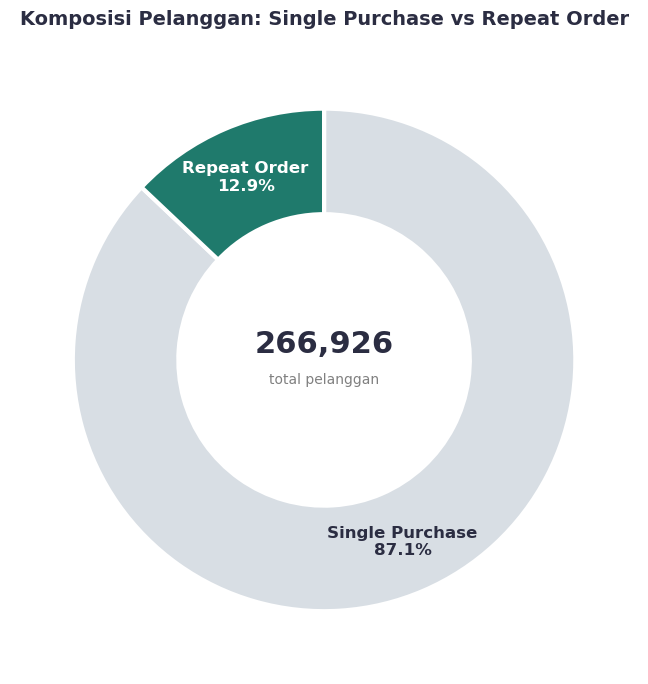

In [27]:
counts = df_final['Target'].value_counts().sort_index()
labels = ['Single Purchase', 'Repeat Order']
colors = [PALETTE['base'], PALETTE['accent']]
pct = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(7, 7))
wedges, _ = ax.pie(counts, colors=colors, startangle=90, counterclock=False,
                    wedgeprops=dict(width=0.42, edgecolor='white', linewidth=3))
for i, w in enumerate(wedges):
    ang = (w.theta2 + w.theta1) / 2
    x, y = np.cos(np.radians(ang)), np.sin(np.radians(ang))
    ax.annotate(f"{labels[i]}\n{pct.iloc[i]:.1f}%", xy=(x * 0.79, y * 0.79), ha='center', va='center',
                fontsize=12, fontweight='bold', color='white' if i == 1 else PALETTE['text'])

ax.text(0, 0.06, f"{counts.sum():,}", ha='center', va='center', fontsize=22, fontweight='bold', color=PALETTE['text'])
ax.text(0, -0.08, "total pelanggan", ha='center', va='center', fontsize=10, color='grey')
ax.set_title("Komposisi Pelanggan: Single Purchase vs Repeat Order", fontsize=14, pad=15)

plt.tight_layout()
plt.show()

Dari total 266.926 pelanggan, mayoritas absolut (87,1%) adalah nasabah Single Purchase, berbanding jauh dengan nasabah Repeat Order yang hanya menyentuh angka 12,9%. Kondisi ini secara bisnis mengindikasikan tingkat retensi pelanggan yang rendah. karena ada masalah imbalance pada project ini, kami akan menggunakan pendekatan oversampling agar model tidak bias memprediksi data mayoritas

**Bivariate analysis**

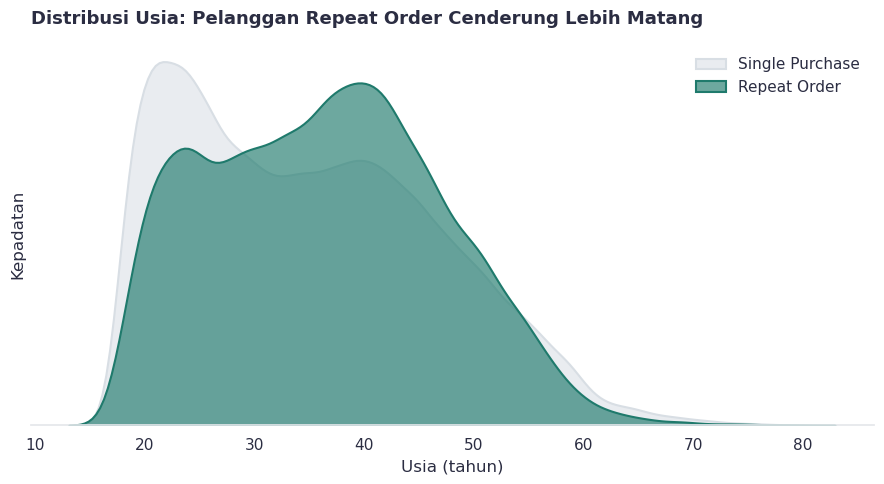

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(data=df_final[df_final['Target'] == 0], x='umur', fill=True, color=PALETTE['base'],
            alpha=0.55, linewidth=1.5, label='Single Purchase', ax=ax)
sns.kdeplot(data=df_final[df_final['Target'] == 1], x='umur', fill=True, color=PALETTE['accent'],
            alpha=0.65, linewidth=1.5, label='Repeat Order', ax=ax)

ax.set_title('Distribusi Usia: Pelanggan Repeat Order Cenderung Lebih Matang', loc='left', fontsize=13, pad=14)
ax.set_xlabel('Usia (tahun)')
ax.set_ylabel('Kepadatan')
ax.set_yticks([])

sns.despine(ax=ax, left=True)
ax.legend(frameon=False, loc='upper right')
plt.tight_layout()
plt.show()

Terdapat kontras perilaku antara kelompok usia muda dan matang, nasabah berumur 20-an cenderung menjadi pembeli tunggal, asumsi kami adalah karena faktor stabilitas ekonomi yang masih berkembang dan belum adanya kebutuhan mendesak untuk menambah kendaraan. Di sisi lain, nasabah pada rentang usia 35-40 tahun menunjukkan potensi loyalitas yang lebih tinggi (kemungkinan untuk repeat order) karena kemapanan finansial serta kebutuhan keluarga yang lebih kompleks, sehingga mendorong mereka untuk melakukan transaksi tambahan di masa depan.

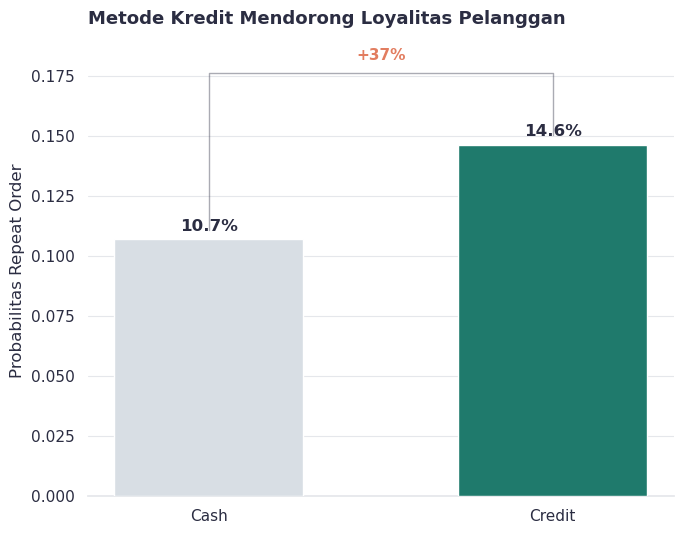

In [29]:
res = df_final.groupby('Cash_Credit')['Target'].mean().reindex([1.0, 2.0], fill_value=0)
res.index = ['Cash', 'Credit']
v1, v2 = res.values
lift = (v2 - v1) / v1 * 100 if v1 > 0 else 0
y_top = max(v1, v2) * 1.28

fig, ax = plt.subplots(figsize=(7, 5.5))
bars = ax.bar(res.index, res.values, color=[PALETTE['base'], PALETTE['accent']], width=0.55, zorder=3)
for b in bars:
    ax.annotate(f'{b.get_height()*100:.1f}%', (b.get_x() + b.get_width() / 2, b.get_height()), xytext=(0, 6),
                textcoords='offset points', ha='center', fontweight='bold', fontsize=12)

ax.plot([0, 0, 1, 1], [v1 + 0.004, y_top * 0.94, y_top * 0.94, v2 + 0.004], color=PALETTE['text'], lw=1, alpha=0.4)
ax.text(0.5, y_top * 0.97, f"+{lift:.0f}%", ha='center', fontsize=11, fontweight='bold', color=PALETTE['accent2'])

ax.set_ylim(0, y_top)
ax.set_title("Metode Kredit Mendorong Loyalitas Pelanggan", loc='left', fontsize=13, pad=16)
ax.set_ylabel("Probabilitas Repeat Order")
style_ax(ax, grid_axis='y')
plt.tight_layout()
plt.show()

Pengguna metode Credit memiliki probabilitas repeat order sebesar 14,65%, jauh lebih tinggi dibandingkan pengguna Cash yang hanya 10,70%. pelanggan yang menggunakan kredit memiliki kecenderungan 37% lebih besar untuk kembali bertransaksi dibandingkan mereka yang membayar tunai. asumsi kami kenapa ini bisa terjadi adalah karena menyiapkan dana tunai besar untuk transaksi kedua seringkali lebih sulit dibandingkan sekadar menggunakan kembali limit kredit yang sudah ada

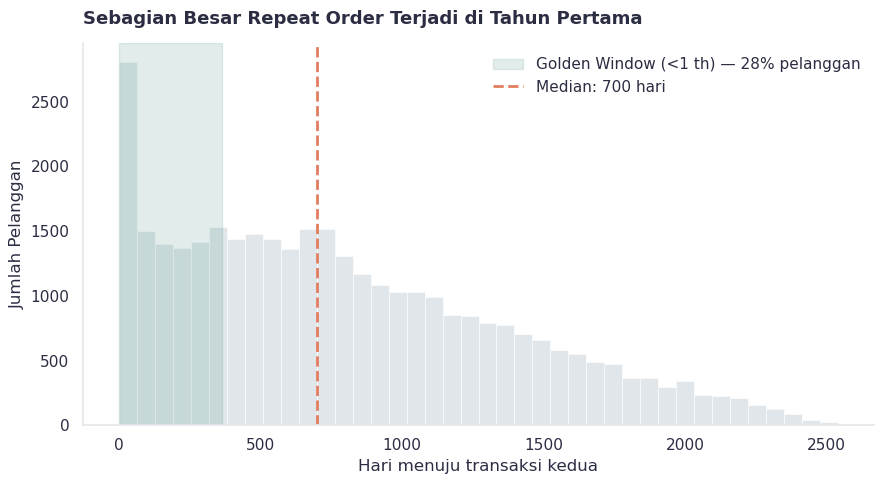

In [30]:
df_rep = df_final[df_final['Target'] == 1].dropna(subset=['durasi_hari_repeat'])
med = df_rep['durasi_hari_repeat'].median()
within_1y = (df_rep['durasi_hari_repeat'] <= 365).mean() * 100

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df_rep['durasi_hari_repeat'], bins=40, color=PALETTE['base'], ax=ax, edgecolor='white', linewidth=0.4)
ax.axvspan(0, 365, color=PALETTE['accent'], alpha=0.13, label=f'Golden Window (<1 th) — {within_1y:.0f}% pelanggan')
ax.axvline(med, color=PALETTE['accent2'], ls='--', lw=2, label=f'Median: {med:.0f} hari')

ax.set_title("Sebagian Besar Repeat Order Terjadi di Tahun Pertama", loc='left', fontsize=13, pad=14)
ax.set_xlabel("Hari menuju transaksi kedua")
ax.set_ylabel("Jumlah Pelanggan")
sns.despine(ax=ax)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Konsentrasi tertinggi pelanggan (28%) melakukan transaksi ulang pada tahun pertama (Golden Window). Namun, nilai tengah (median) pada angka 700 hari menunjukkan bahwa 50% pelanggan sebenarnya membutuhkan waktu sekitar dua tahun atau lebih untuk kembali melakukan pembelian. Berdasarkan distribusi ini, strategi follow-up idealnya dibagi menjadi dua fase. pertama bisa melakukan penawaran pada 365 hari pertama untuk menangkap momentum konversi cepat, dilanjutkan dengan program pemeliharaan hubungan pelanggan secara berkala hingga memasuki tahun kedua untuk menjaring kelompok yang membutuhkan waktu lebih lama.

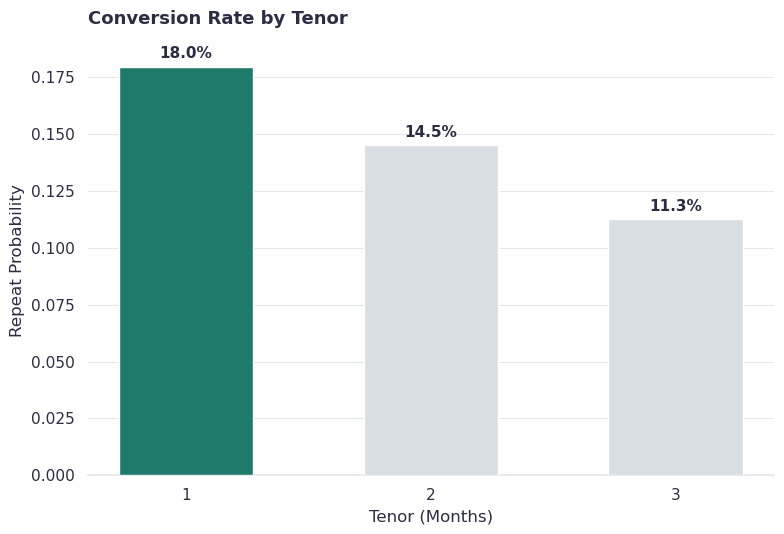

In [31]:
tenor_eval = df_final.dropna(subset=['Tenor_max']).groupby('Tenor_max')['Target'].mean().reset_index()
tenor_eval = tenor_eval.sort_values('Tenor_max')
colors = [PALETTE['accent'] if v == tenor_eval['Target'].max() else PALETTE['base'] for v in tenor_eval['Target']]

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.bar(tenor_eval['Tenor_max'], tenor_eval['Target'], color=colors, width=0.55, zorder=3)
for b in bars:
    ax.annotate(f'{b.get_height()*100:.1f}%', (b.get_x() + b.get_width() / 2, b.get_height()), xytext=(0, 6),
                textcoords='offset points', ha='center', fontweight='bold', fontsize=11)

ax.set_title("Conversion Rate by Tenor", loc='left', fontsize=13, pad=16)
ax.set_ylabel("Repeat Probability")
ax.set_xlabel("Tenor (Months)")
style_ax(ax, grid_axis='y')
plt.tight_layout()
plt.show()

Nasabah yang mengambil jangka waktu paling pendek justru paling berpotensi kembali bertransaksi, Semakin panjang masa pinjaman, peluang nasabah untuk melakukan RO justru semakin menurun. ini menunjukan nasabah dengan tenor pendek cenderung memiliki kapasitas finansial yang lebih kuat karena mampu membayar cicilan bulanan yang lebih besar dalam waktu singkat. Begitu cicilan lunas dalam 1 tahun, mereka segera memiliki "ruang" di arus kas mereka untuk mengajukan kredit baru.

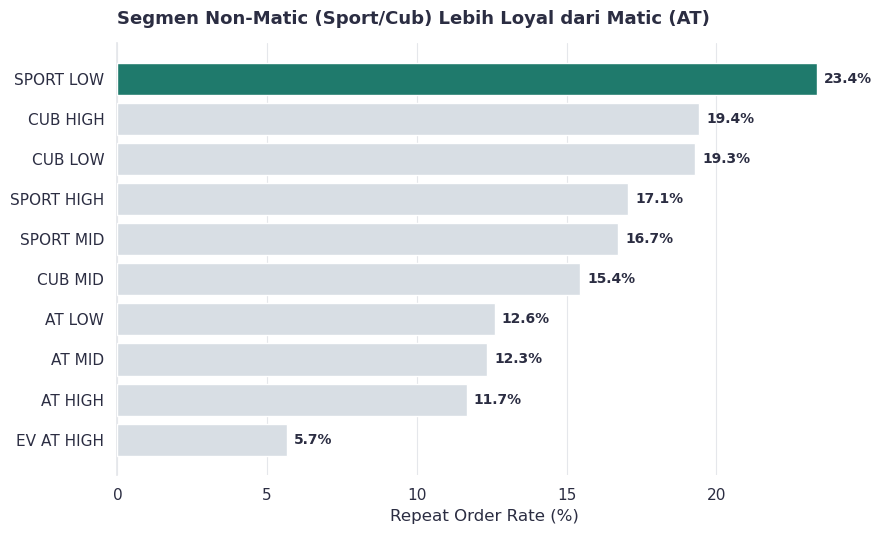

In [32]:
seg = df_final.groupby('segment')['Target'].agg(['mean', 'count']).sort_values('mean', ascending=False)
seg = seg[seg['count'] >= 50]  # buang segmen dengan sampel terlalu kecil agar tidak menyesatkan
colors = [PALETTE['accent'] if v == seg['mean'].max() else PALETTE['base'] for v in seg['mean']]

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(seg.index[::-1], seg['mean'][::-1] * 100, color=colors[::-1], zorder=3)
for b in bars:
    ax.annotate(f'{b.get_width():.1f}%', (b.get_width(), b.get_y() + b.get_height() / 2), xytext=(5, 0),
                textcoords='offset points', va='center', fontsize=10, fontweight='bold')
ax.set_title("Segmen Non-Matic (Sport/Cub) Lebih Loyal dari Matic (AT)", loc='left', fontsize=13, pad=14)
ax.set_xlabel("Repeat Order Rate (%)")
style_ax(ax, grid_axis='x')
plt.tight_layout()
plt.show()

Pelanggan pada segmen kendaraan non-matic menunjukkan probabilitas pembelian ulang yang lebih tinggi dibandingkan segmen matic. Kategori SPORT LOW memimpin konversi tertinggi di angka 23,4%, disusul oleh varian CUB dan SPORT lainnya yang konsisten berada di rentang 15-19%. Kinerja ini berjarak cukup signifikan dari seluruh lini matic (AT LOW/MID/HIGH) yang tingkat retensinya cenderung tertahan di kisaran 12%. Sementara itu, segmen EV AT HIGH mencatatkan persentase terendah (5,7%)

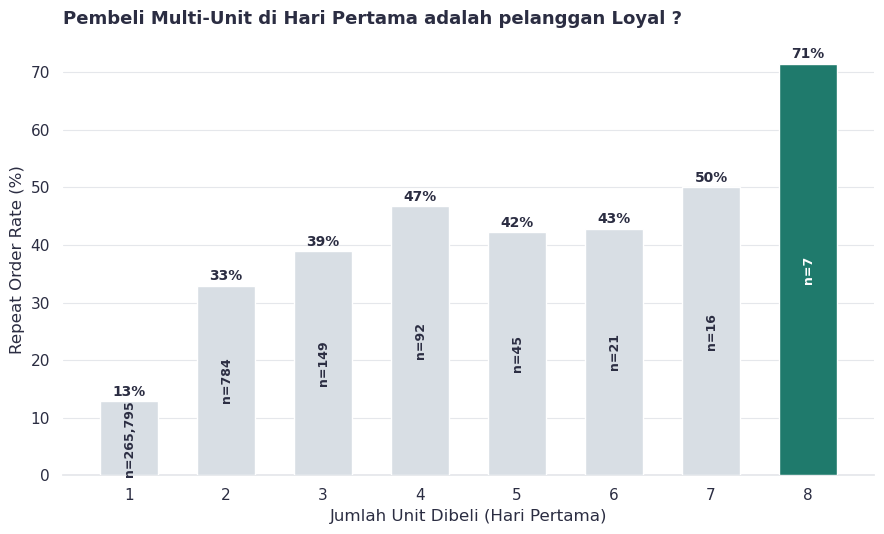

In [33]:
# Grouping menggunakan kolom Jml_Unit asli, dengan filter minimal 5 sampel
ju = df_final.groupby('Jml_Unit')['Target'].agg(['mean', 'count'])
ju = ju[ju['count'] >= 5].reset_index()

# Menentukan warna: hijau (accent) untuk nilai tertinggi, abu-abu (base) untuk sisanya
colors = [PALETTE['accent'] if v == ju['mean'].max() else PALETTE['base'] for v in ju['mean']]

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(ju['Jml_Unit'].astype(str), ju['mean'] * 100, color=colors, zorder=3, width=0.6)

for i, b in enumerate(bars):
    # Anotasi persentase Repeat Order di atas bar
    ax.annotate(f"{b.get_height():.0f}%", (b.get_x() + b.get_width() / 2, b.get_height()), xytext=(0, 4),
                textcoords='offset points', ha='center', fontsize=10, fontweight='bold')
    
    # Anotasi jumlah populasi (n) di tengah bar
    count_val = ju['count'].iloc[i]
    ax.annotate(f"n={count_val:,}", (b.get_x() + b.get_width() / 2, b.get_height() / 2),
                ha='center', va='center', fontsize=9, fontweight='bold', rotation=90,
                color='white' if colors[i] == PALETTE['accent'] else PALETTE['text'])

ax.set_title("Pembeli Multi-Unit di Hari Pertama adalah pelanggan Loyal ?", loc='left', fontsize=13, pad=14)
ax.set_xlabel("Jumlah Unit Dibeli (Hari Pertama)")
ax.set_ylabel("Repeat Order Rate (%)")
style_ax(ax, grid_axis='y')

plt.tight_layout()
plt.show()

Terdapat indikasi bahwa probabilitas repeat order meningkat seiring dengan bertambahnya jumlah unit yang dibeli pada transaksi perdana—merangkak dari 13% untuk 1 unit, hingga mencapai puncak 71% pada pembelian 8 unit. Meskipun demikian, perlu dicatat bahwa jumlah populasi ($n$) pada pembelian 3 unit ke atas sangatlah kecil. Oleh karena itu, perlu dilakukan uji statistik lebih lanjut untuk memvalidasi apakah faktor jumlah unit ini benar-benar prediktor yang signifikan atau sekadar anomali akibat minimnya ukuran sampel.

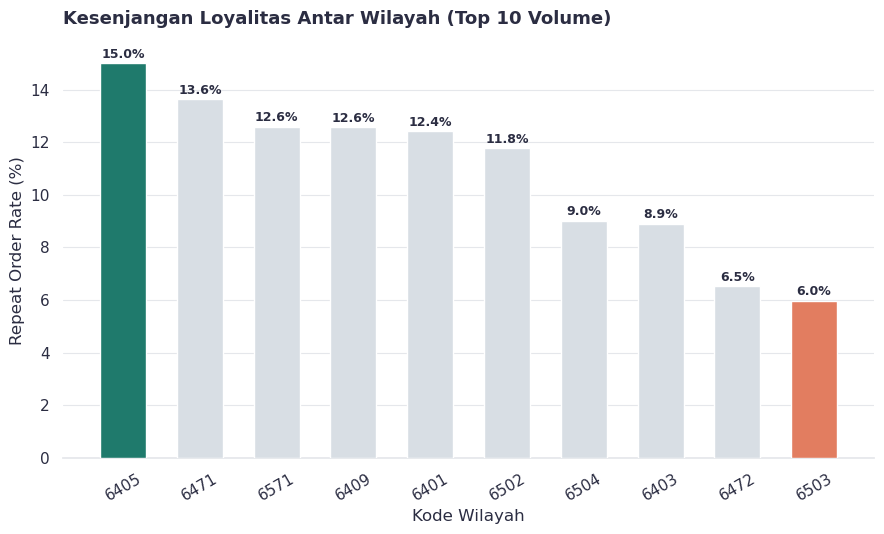

In [34]:
top_wilayah = df_final['wilayah'].value_counts().head(10).index
w = df_final[df_final['wilayah'].isin(top_wilayah)].groupby('wilayah')['Target'].agg(['mean', 'count']).sort_values('mean', ascending=False)
colors = [PALETTE['accent'] if v == w['mean'].max() else (PALETTE['accent2'] if v == w['mean'].min() else PALETTE['base']) for v in w['mean']]

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(w.index.astype(str), w['mean'] * 100, color=colors, zorder=3, width=0.6)
for b in bars:
    ax.annotate(f'{b.get_height():.1f}%', (b.get_x() + b.get_width() / 2, b.get_height()), xytext=(0, 4),
                textcoords='offset points', ha='center', fontsize=9, fontweight='bold')
ax.set_title("Kesenjangan Loyalitas Antar Wilayah (Top 10 Volume)", loc='left', fontsize=13, pad=14)
ax.set_xlabel("Kode Wilayah")
ax.set_ylabel("Repeat Order Rate (%)")
ax.tick_params(axis='x', rotation=30)
style_ax(ax, grid_axis='y')
plt.tight_layout()
plt.show()

Pada sepuluh wilayah dengan volume transaksi terbesar, tingkat pembelian ulang menunjukkan ketimpangan yang signifikan dengan rentang 6,0% hingga 15,0%. Wilayah 6405 dan 6471 memimpin performa dengan tingkat retensi tertinggi di atas rata-rata. Sebaliknya, wilayah 6503 dan 6472 mencatatkan tingkat loyalitas terendah di kisaran 6%. Wilayah 6503 dan 6472 sangat sukses dalam mengakuisisi pembeli baru (terbukti dari posisinya di Top 10 Volume), namun ,masih belum maksimal mengonversi mereka menjadi pelanggan jangka panjang.

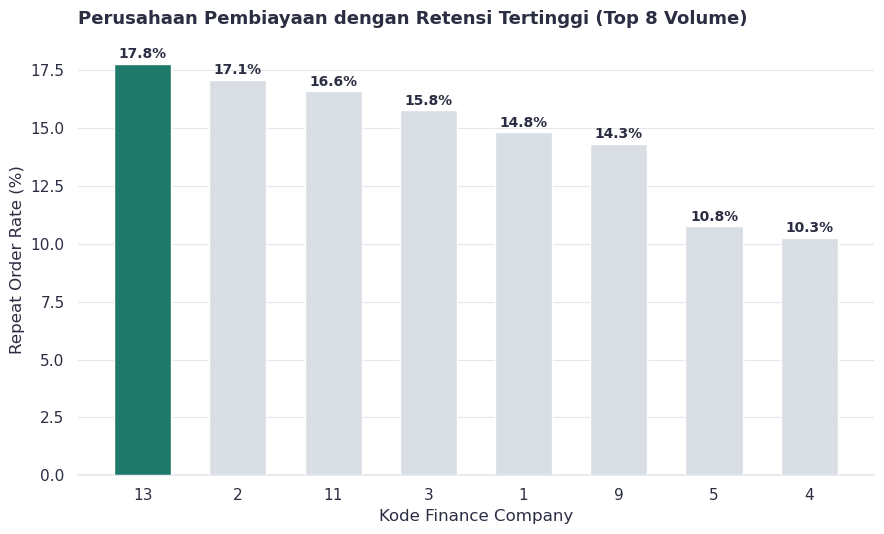

In [35]:
top_fc = df_final['Finance_Company'].value_counts().head(8).index
f = df_final[df_final['Finance_Company'].isin(top_fc)].groupby('Finance_Company')['Target'].agg(['mean', 'count']).sort_values('mean', ascending=False)
colors = [PALETTE['accent'] if v == f['mean'].max() else PALETTE['base'] for v in f['mean']]

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(f.index.astype(str), f['mean'] * 100, color=colors, zorder=3, width=0.6)
for b in bars:
    ax.annotate(f'{b.get_height():.1f}%', (b.get_x() + b.get_width() / 2, b.get_height()), xytext=(0, 4),
                textcoords='offset points', ha='center', fontsize=10, fontweight='bold')
ax.set_title("Perusahaan Pembiayaan dengan Retensi Tertinggi (Top 8 Volume)", loc='left', fontsize=13, pad=14)
ax.set_xlabel("Kode Finance Company")
ax.set_ylabel("Repeat Order Rate (%)")
style_ax(ax, grid_axis='y')
plt.tight_layout()
plt.show()

tingkat pelanggan yang kembali lagi (loyalitas) berbeda-beda tergantung pada perusahaan pembiayaan yang dipilih, dengan rentang antara 10,3% sampai 17,8%. Ini membuktikan bahwa kerjasama dealer dengan pihak pembiayaan tidak bisa hanya dinilai dari seberapa mudah mereka menyetujui pinjaman. Dealer perlu memilih mitra yang skema cicilannya mampu membuat pelanggan puas, sehingga mereka tertarik untuk kembali membeli motor lagi di masa depan.

## <b> Statistical Testing

In [36]:
# uji apakah umur berpengaruh secara signifikan
age_target_0 = df_final[df_final['Target'] == 0]['umur'].dropna()
age_target_1 = df_final[df_final['Target'] == 1]['umur'].dropna()
u_stat, p_val_age = mannwhitneyu(age_target_0, age_target_1, alternative='two-sided')
print(f"Mann-Whitney Test (Umur vs Target) P-Value: {p_val_age:.4e}")

Mann-Whitney Test (Umur vs Target) P-Value: 4.8496e-150


In [37]:
# uji apakah cash/credit berpengaruh signigikan
contingency_table = pd.crosstab(df_final['Cash_Credit'], df_final['Target'])
chi2, p_chi2, _, _ = chi2_contingency(contingency_table)
print(f"Method vs Target (Chi-Square): P-Value = {p_chi2:.4f}")

Method vs Target (Chi-Square): P-Value = 0.0000


In [38]:
# uji apakah durasi kembali belanja berbeda signifikan
rep_only = df_final[df_final['Target'] == 1].dropna(subset=['durasi_hari_repeat'])
group_cash = rep_only[rep_only['Cash_Credit'] == 1.0]['durasi_hari_repeat']
group_credit = rep_only[rep_only['Cash_Credit'] == 2.0]['durasi_hari_repeat']
u_stat, p_durasi = mannwhitneyu(group_cash, group_credit)
print(f"Durasi vs Method (Mann-Whitney): P-Value = {p_durasi:.4f}")

Durasi vs Method (Mann-Whitney): P-Value = 0.0000


In [39]:
df_stats = df_final.copy()
df_stats['Tenor_max'] = pd.to_numeric(df_stats['Tenor_max'], errors='coerce')
df_stats = df_stats.dropna(subset=['Tenor_max'])

# man whitney statistical test per target class
t0 = df_stats[df_stats['Target'] == 0]['Tenor_max']
t1 = df_stats[df_stats['Target'] == 1]['Tenor_max']
stat, p_tenor = mannwhitneyu(t0, t1)

print(f"P-Value Tenor: {p_tenor:.4f}")

P-Value Tenor: 0.0000


hasilnya pada semua variable memiliki p value < 0.05, artinya perbedaan nilai di setiap variable (umur, metode pembayatan, recency days dan durasi tenor) terbutki valid secara statistik sebagai pembeda nilai target (apakah pelanggan kembali membeli atau tidak)

In [40]:
# Finance Company vs Target
contingency_finance = pd.crosstab(df_final['Finance_Company'], df_final['Target'])
chi2, p_finance, _, _ = chi2_contingency(contingency_finance)
print(f"Finance Company vs Target (Chi-Square) P-Value: {p_finance:.4f}")

# Wilayah vs Target
contingency_wilayah = pd.crosstab(df_final['wilayah'], df_final['Target'])
chi2, p_wilayah, _, _ = chi2_contingency(contingency_wilayah)
print(f"Wilayah vs Target (Chi-Square) P-Value: {p_wilayah:.4f}")

# Jml_Unit vs Target
contingency_unit = pd.crosstab(df_final['Jml_Unit'], df_final['Target'])
chi2, p_unit, _, _ = chi2_contingency(contingency_unit)
print(f"Jml_Unit vs Target (Chi-Square) P-Value: {p_unit:.4f}")

# Segmen (Matic vs Non-Matic) vs Target
df_final['is_matic'] = df_final['segment'].str.contains('AT', case=False, na=False)
contingency_segmen = pd.crosstab(df_final['is_matic'], df_final['Target'])
chi2, p_segmen, _, _ = chi2_contingency(contingency_segmen)
print(f"Segmen Matic vs Target (Chi-Square) P-Value: {p_segmen:.4f}")

Finance Company vs Target (Chi-Square) P-Value: 0.0000
Wilayah vs Target (Chi-Square) P-Value: 0.0000
Jml_Unit vs Target (Chi-Square) P-Value: 0.0000
Segmen Matic vs Target (Chi-Square) P-Value: 0.0000


Seluruh variabel yang diuji—meliputi perusahaan pembiayaan, wilayah, jumlah unit pembelian perdana, hingga segmen motor (Matic vs Non-Matic)—menunjukkan nilai p-value sebesar 0,0000. Secara statistik, ini membuktikan bahwa setiap faktor tersebut memiliki hubungan yang signifikan dalam membedakan nasabah yang melakukan repeat order dengan nasabah pembelian tunggal.

Temuan yang paling menarik adalah pada variabel Jumlah Unit (Jml_Unit). Meskipun populasi pelanggan yang membeli banyak unit sekaligus dalam satu hari sangat kecil dibandingkan pembeli unit tunggal, hasil uji Chi-Square tetap memberikan signifikansi yang valid. mengkonfirmasi bahwa perilaku pembelian multi-unit bukanlah anomali acak, melainkan pembeda (prediktor) yang kuat

## **Feature engineering**

In [41]:
df_final.head()

,Customer ID,OTR_sum,DP_sum,Cicilan_sum,umur,Cash_Credit,Pekerjaan,Gender,wilayah,Kode_POS,...,Tenor_max,Jml_Unit,Finance_Company,type_series,segment,dealer,Target,tgl_mohon_kedua,durasi_hari_repeat,is_matic
0,CUST-00001,22965000.0,22965000.0,12500000.0,40.0,2.0,4f,2,6471,76116,...,1,1,1,scooty series,AT MID,Balikpapan,0,NaT,NaN,True
1,CUST-00002,335205000.0,0.0,0.0,42.0,1.0,nan,None,6471,76111,...,None,13,None,varex 150,AT HIGH,Balikpapan,1,2019-04-11,1.0,True
2,CUST-00003,51570000.0,0.0,0.0,31.0,1.0,11,1,6471,76111,...,None,2,None,varex 150,AT HIGH,Balikpapan,1,2019-04-11,1.0,True
3,CUST-00004,114520000.0,0.0,0.0,32.0,1.0,nan,None,6471,76115,...,None,4,None,breez sport,AT LOW,Balikpapan,1,2025-12-01,1096.0,True
4,CUST-00005,88280000.0,0.0,0.0,40.0,1.0,8,1,6409,76145,...,None,4,None,vexa series,SPORT LOW,Balikpapan,1,2021-11-22,500.0,False


**Financial feature**

In [42]:
df_final['Is_Credit'] = np.where(df_final['Cash_Credit'] == 2.0, 1, 0)

Memberikan indikator biner dari Cash_Credit, representasinya diubah dari 2 (kredit) dan 1 (cash) menjadi binary representation dimana 1 itu berarti menggunakan credit dan 0 adalah cash

In [43]:
df_final['Short_Tenor'] = np.where(df_final['Tenor_max'] == '1', 1, 0)

analisis sebelumnya menunjukkan bahwa nasabah dengan jangka waktu cicilan terpendek memiliki probabilitas pembelian ulang yang lebih tinggi, variabel ini berfungsi untuk menangkap pola dimana tenor pendek cenderung melakukan pembelian kembali, sehingga machine learning nantinya bisa belajar pola tenor ini sesuai dengan temuan di EDA

In [44]:
df_final['DP_Ratio'] = np.where(df_final['OTR_sum'] > 0, df_final['DP_sum'] / df_final['OTR_sum'], 0.0)
df_final['DP_Log'] = np.log1p(df_final['DP_sum'])

DP_Ratio dibuat untuk menormalisasi besaran uang muka terhadap harga motor (OTR). Hal ini memungkinkan model untuk memahami proporsi kemampuan finansial pelanggan dalam memberikan uang muka, sehingga perbandingan antara pembeli motor murah dan mahal menjadi setara dalam skala 0 hingga 1. hasilnya kemudian di log scale karena distribusinya skewed

In [45]:
df_final['Estimasi_Kredit'] = df_final['OTR_sum'] - df_final['DP_sum']
df_final['Beban_Cicilan_Bulanan'] = df_final['Cicilan_sum']
df_final['Cicilan_to_OTR_Ratio'] = np.where(df_final['OTR_sum'] > 0, df_final['Beban_Cicilan_Bulanan'] / df_final['OTR_sum'], 0.0)

Mengukur beban hutang nasabah. Rasio cicilan terhadap harga total memberikan gambaran seberapa berat tanggungan bulanan mereka relatif terhadap aset yang dibeli.

Cicilan_to_OTR_Ratio dibuat untuk menormalkan beban cicilan terhadap harga unit. Rasio ini membantu model memahami seberapa berat beban cicilan dibandingkan dengan nilai kendaraan yang dibeli, yang seringkali menjadi penentu utama apakah pelanggan akan mampu dan mau melakukan transaksi kembali di masa depan

**Demographic feature**

In [46]:
# flag non matic
df_final['Is_NonMatic_Segment'] = df_final['segment'].str.upper().str.startswith(('CUB', 'SPORT')).astype(int)

karena pada hasil EDA pelanggan yang memiliki kemungkinan kembali belanja jika dilihat dari tipe motor yang dibeli non-matic lebih tinggi probabilitasnya, disini dibuatkan feature agar model bisa menangkap pola tersebut (flag kalau non matic 1, matic 0)

In [47]:
df_final['CLV_Proxy'] = df_final['OTR_sum'] * df_final['Jml_Unit']

Customer Lifetime Value (CLV) di hari pertama. Nasabah yang langsung membeli banyak unit atau unit mahal memiliki nilai lebih tinggi bagi perusahaan dan sering kali memiliki profil risiko atau loyalitas yang berbeda. tujuannya untuk membantu model mengidentifikasi karena nasabah dengan CLV yang tinggi (beli banyak di hari pertama) memiliki loyalitas yang tinggi dan punya probabilitas untuk repeat order jika dilihat dari EDA

In [48]:
df_final['Age_Group'] = pd.cut(df_final['umur'], bins=[0, 25, 35, 45, 100], labels=['<25', '25-35', '36-45', '>45'])
df_final = df_final.drop(columns=['umur'])

Seperti yang terlihat pada grafik distribusi umur sebelumnya, hubungan antara usia dan Repeat Order tidak bersifat linear. Pengelompokan ini membantu model untuk lebih mudah mengenali pola perilaku spesifik di tiap nasabah.

**Aggregation feature**

In [49]:
df_final['Bulan_Beli_Pertama'] = df_final['tgl_mohon'].dt.month
df_final['Tahun_Beli_Pertama'] = df_final['tgl_mohon'].dt.year

Membantu model mendeteksi pola musiman. Misalnya, apakah nasabah yang membeli saat promo akhir tahun atau Lebaran memiliki kecenderungan Repeat Order yang berbeda dibandingkan bulan biasa.

In [50]:
max_date_in_data = df_final['tgl_mohon'].max()
df_final['Recency_Days'] = (max_date_in_data - df_final['tgl_mohon']).dt.days

nasabah yang lebih baru bertransaksi seringkali memiliki perilaku yang berbeda dengan nasabah lama. Fitur ini memberikan gambaran seberapa lama nasabah tersebut berinteraksi dengan bisnis

**Feature engineering result exploration**

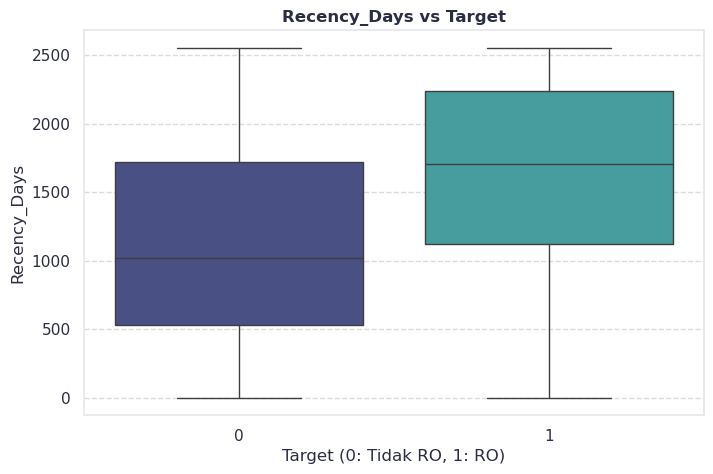

In [51]:
# recency days
plt.figure(figsize=(8, 5))
sns.boxplot(x='Target', y='Recency_Days', data=df_final, palette='mako')
plt.title('Recency_Days vs Target', fontweight='bold')
plt.xlabel('Target (0: Tidak RO, 1: RO)')
plt.ylabel('Recency_Days')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Nasabah yang sudah bergabung sangat lama (misal 4-5 tahun lalu) memiliki peluang lebih besar untuk tercatat sebagai RO karena mereka sudah melewati siklus kebutuhan kendaraan baru atau masa pelunasan kredit. Nasabah yang baru bergabung dalam 1 tahun terakhir terlihat tidak loyal (Target 0) bukan karena mereka tidak mau kembali, melainkan karena waktunya belum cukup bagi mereka untuk melakukan transaksi kedua.

In [52]:
# remove outlier
Q1 = df_final['Cicilan_to_OTR_Ratio'].quantile(0.25)
Q3 = df_final['Cicilan_to_OTR_Ratio'].quantile(0.75)
IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

df_final = df_final[(df_final['Cicilan_to_OTR_Ratio'] >= batas_bawah) & (df_final['Cicilan_to_OTR_Ratio'] <= batas_atas)]

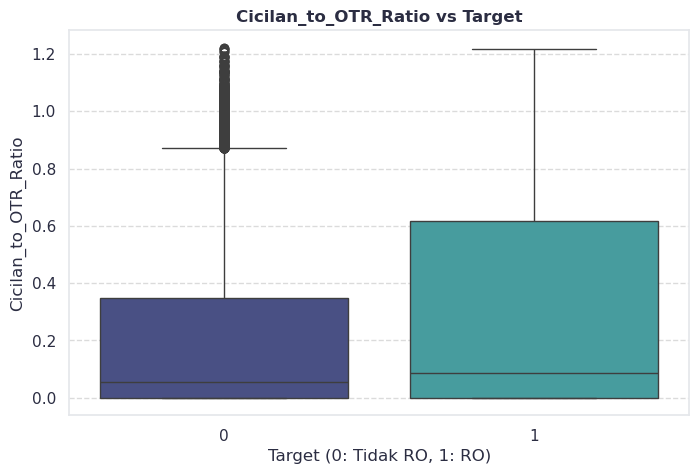

In [53]:
# Cicilan_to_OTR_Ratio
plt.figure(figsize=(8, 5))
sns.boxplot(x='Target', y='Cicilan_to_OTR_Ratio', data=df_final, palette='mako')
plt.title('Cicilan_to_OTR_Ratio vs Target', fontweight='bold')
plt.xlabel('Target (0: Tidak RO, 1: RO)')
plt.ylabel('Cicilan_to_OTR_Ratio')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Nasabah loyal cenderung memiliki rasio cicilan terhadap OTR yang lebih tinggi, mengindikasikan kapasitas finansial kuat dan penggunaan tenor pendek yang memungkinkan mereka lebih cepat bertransaksi kembali. Sebaliknya, nasabah sekali beli didominasi oleh rasio rendah atau beban cicilan ekstrem yang menghambat terjadinya transaksi kedua.

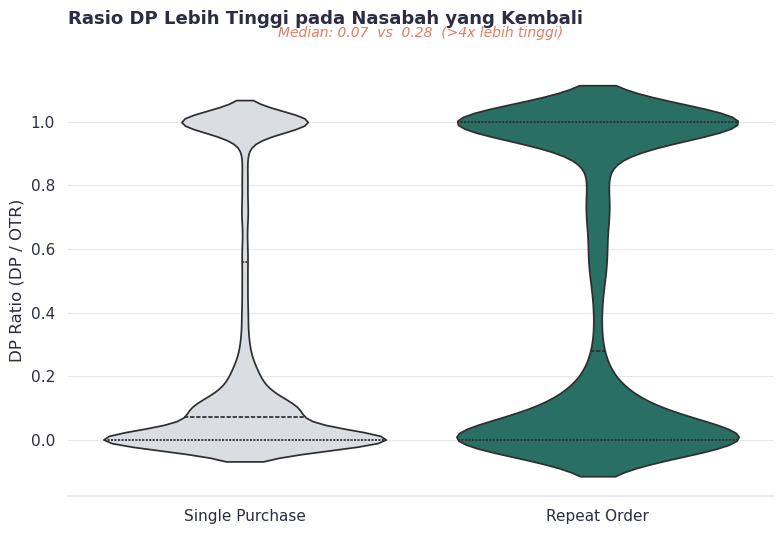

In [54]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.violinplot(data=df_final, x='Target', y='DP_Ratio', hue='Target', 
               palette=[PALETTE['base'], PALETTE['accent']],
               legend=False, ax=ax, inner='quartile')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Single Purchase', 'Repeat Order'])

ax.set_title("Rasio DP Lebih Tinggi pada Nasabah yang Kembali", loc='left', fontsize=13, pad=30)
ax.set_xlabel('')
ax.set_ylabel('DP Ratio (DP / OTR)')
style_ax(ax, grid_axis='y')

med0 = df_final[df_final['Target'] == 0]['DP_Ratio'].median()
med1 = df_final[df_final['Target'] == 1]['DP_Ratio'].median()
ax.text(0.5, 1.06, f"Median: {med0:.2f}  vs  {med1:.2f}  (>4x lebih tinggi)", 
        transform=ax.transAxes, ha='center', va='bottom', 
        fontsize=10, style='italic', color=PALETTE['accent2'])

plt.tight_layout()
plt.show()

DP_Ratio menguatkan insight dari Cicilan_to_OTR_Ratio sebelumnya, dimana nasabah yang repeat order punya median DP Ratio **0,31**, lebih dari 4x lipat dibanding nasabah single-purchase (**0,07**). Down payment yang lebih besar mengindikasikan kapasitas finansial dan komitmen yang lebih kuat di awal dan dua hal ini konsisten muncul di beberapa fitur finansial berbeda, jadi sinyalnya cukup kuat, bukan kebetulan.

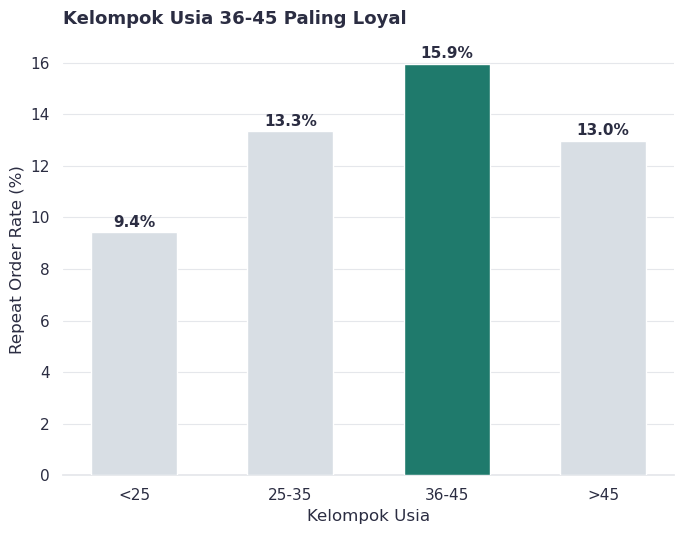

In [55]:
ag = df_final.groupby('Age_Group', observed=True)['Target'].mean().reindex(['<25', '25-35', '36-45', '>45'])
colors = [PALETTE['accent'] if v == ag.max() else PALETTE['base'] for v in ag]

fig, ax = plt.subplots(figsize=(7, 5.5))
bars = ax.bar(ag.index, ag.values * 100, color=colors, zorder=3, width=0.55)
for b in bars:
    ax.annotate(f'{b.get_height():.1f}%', (b.get_x() + b.get_width() / 2, b.get_height()), xytext=(0, 4),
                textcoords='offset points', ha='center', fontsize=11, fontweight='bold')
ax.set_title("Kelompok Usia 36-45 Paling Loyal", loc='left', fontsize=13, pad=14)
ax.set_xlabel("Kelompok Usia")
ax.set_ylabel("Repeat Order Rate (%)")
style_ax(ax, grid_axis='y')
plt.tight_layout()
plt.show()

Versi kategorikal dari distribusi usia yang sudah dilihat lewat KDE plot sebelumnya, Kelompok usia **36-45 tahun** paling loyal (16,0%), sementara **<25 tahun** paling rendah (9,4%). Pola ini masuk akal karena usia 36-45 biasanya sudah settled secara finansial (karir & keluarga), sehingga pembelian kendaraan tambahan/pengganti lebih mungkin terjadi dibanding nasabah yang baru mulai bekerja.

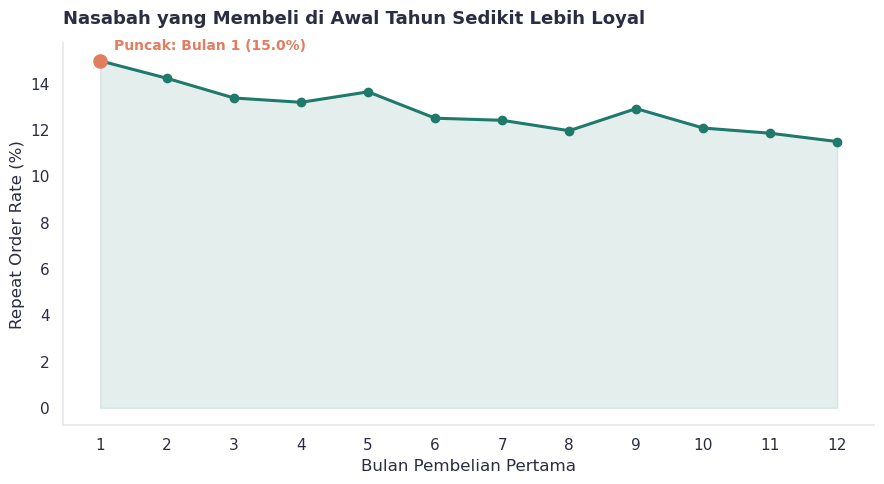

In [56]:
bulan_pertama = df_final['tgl_mohon'].dt.month
seas = df_final.groupby(bulan_pertama)['Target'].mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(seas.index, seas.values * 100, color=PALETTE['accent'], marker='o', linewidth=2.2, zorder=3)
ax.fill_between(seas.index, seas.values * 100, color=PALETTE['accent'], alpha=0.12)
peak = seas.idxmax()
ax.scatter([peak], [seas[peak] * 100], color=PALETTE['accent2'], s=90, zorder=4)
ax.annotate(f"Puncak: Bulan {peak} ({seas[peak]*100:.1f}%)", (peak, seas[peak] * 100), xytext=(10, 8),
            textcoords='offset points', fontsize=10, fontweight='bold', color=PALETTE['accent2'])
ax.set_xticks(range(1, 13))
ax.set_title("Nasabah yang Membeli di Awal Tahun Sedikit Lebih Loyal", loc='left', fontsize=13, pad=14)
ax.set_xlabel("Bulan Pembelian Pertama")
ax.set_ylabel("Repeat Order Rate (%)")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

Repeat order rate tertinggi ada pada nasabah yang pertama kali membeli di bulan **Januari (15,0%)**, menurun bertahap sepanjang tahun hingga terendah di **Desember (11,5%)**. Perlu dicatat pola ini bisa dipengaruhi dua hal sekaligus, (1) efek musiman murni seperti promo awal tahun menarik pembeli yang lebih loyal atau (2) sedikit bias recency, karena data digabung dari beberapa tahun sehingga pembeli di bulan-bulan awal tahun secara historis punya rentang waktu kalender sedikit lebih panjang untuk kembali. Insight ini tetap berguna untuk momentum kampanye retensi, tapi bukan bukti sebab-akibat murni musiman.

## **Ringkasan Insight (Executive Dashboard)**

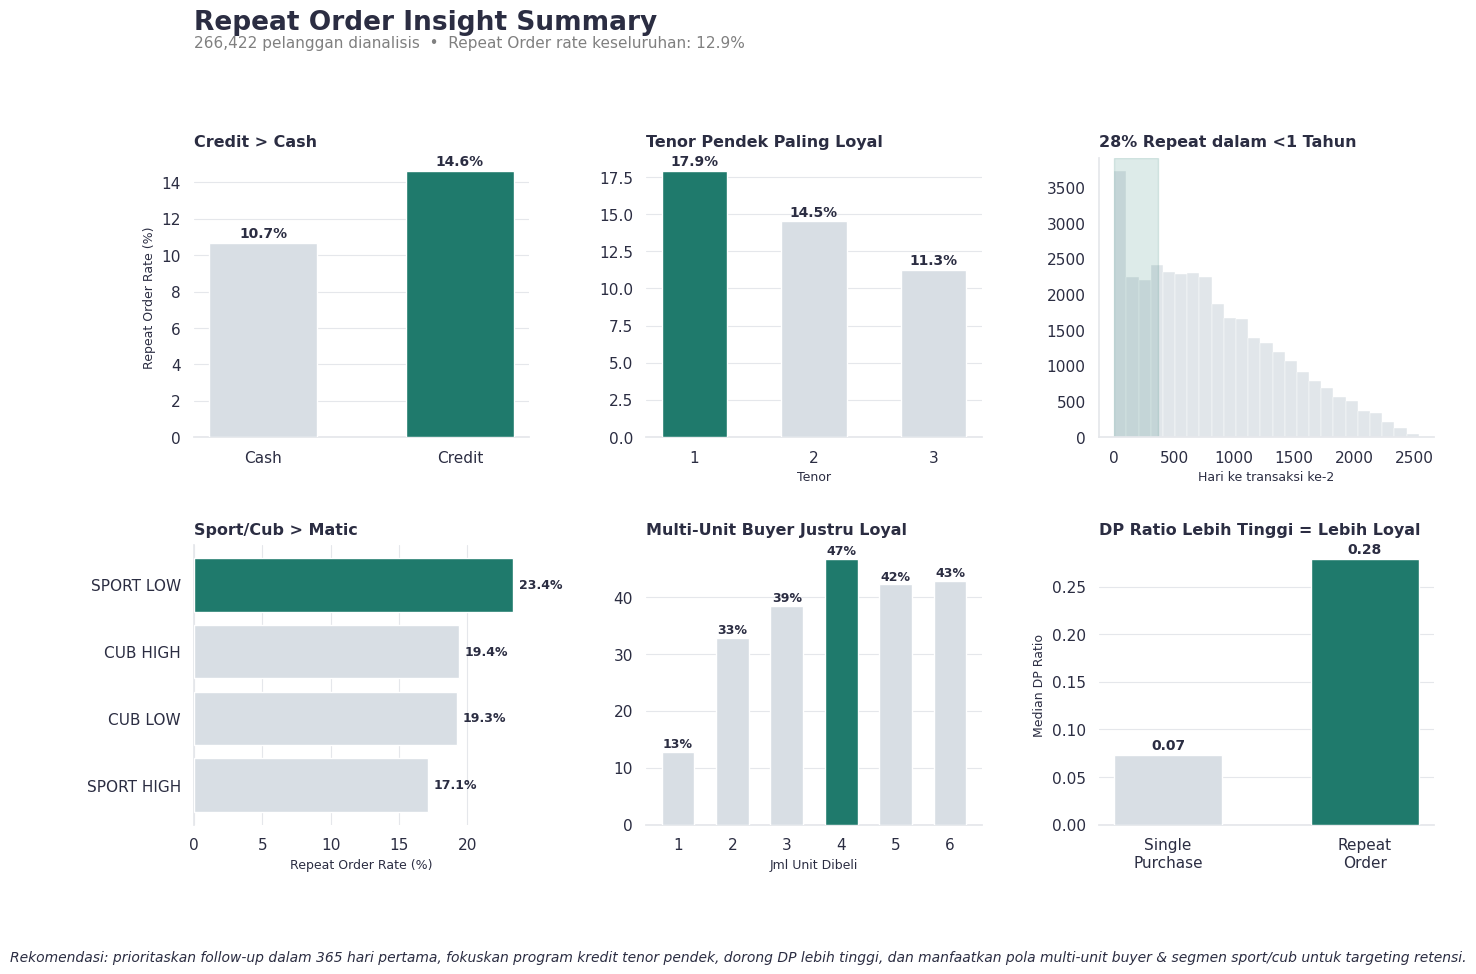

In [57]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 10.5))
gs = gridspec.GridSpec(3, 3, figure=fig, height_ratios=[0.12, 1, 1], hspace=0.55, wspace=0.35)

overall_rate = df_final['Target'].mean() * 100
ax_head = fig.add_subplot(gs[0, :])
ax_head.axis('off')
ax_head.text(0, 0.6, "Repeat Order Insight Summary", fontsize=19, fontweight='bold', color=PALETTE['text'])
ax_head.text(0, 0.05, f"{len(df_final):,} pelanggan dianalisis  \u2022  Repeat Order rate keseluruhan: {overall_rate:.1f}%",
             fontsize=11, color='grey')

# Panel 1: Cash vs Credit
ax1 = fig.add_subplot(gs[1, 0])
res = df_final.groupby('Cash_Credit')['Target'].mean().reindex([1.0, 2.0], fill_value=0)
res.index = ['Cash', 'Credit']
bars = ax1.bar(res.index, res.values * 100, color=[PALETTE['base'], PALETTE['accent']], width=0.55, zorder=3)
for b in bars:
    ax1.annotate(f'{b.get_height():.1f}%', (b.get_x() + b.get_width() / 2, b.get_height()), xytext=(0, 4),
                 textcoords='offset points', ha='center', fontweight='bold', fontsize=10)
ax1.set_title('Credit > Cash', loc='left', fontsize=11.5, pad=8)
ax1.set_ylabel('Repeat Order Rate (%)', fontsize=9)
style_ax(ax1, grid_axis='y')

# Panel 2: Tenor
ax2 = fig.add_subplot(gs[1, 1])
tenor_eval = df_final.dropna(subset=['Tenor_max']).groupby('Tenor_max')['Target'].mean().reset_index().sort_values('Tenor_max')
colors = [PALETTE['accent'] if v == tenor_eval['Target'].max() else PALETTE['base'] for v in tenor_eval['Target']]
bars = ax2.bar(tenor_eval['Tenor_max'], tenor_eval['Target'] * 100, color=colors, width=0.55, zorder=3)
for b in bars:
    ax2.annotate(f'{b.get_height():.1f}%', (b.get_x() + b.get_width() / 2, b.get_height()), xytext=(0, 4),
                 textcoords='offset points', ha='center', fontweight='bold', fontsize=10)
ax2.set_title('Tenor Pendek Paling Loyal', loc='left', fontsize=11.5, pad=8)
ax2.set_xlabel('Tenor', fontsize=9)
style_ax(ax2, grid_axis='y')

# Panel 3: Golden window
ax3 = fig.add_subplot(gs[1, 2])
df_rep = df_final[df_final['Target'] == 1].dropna(subset=['durasi_hari_repeat'])
within_1y = (df_rep['durasi_hari_repeat'] <= 365).mean() * 100
sns.histplot(df_rep['durasi_hari_repeat'], bins=25, color=PALETTE['base'], ax=ax3, edgecolor='white', linewidth=0.3)
ax3.axvspan(0, 365, color=PALETTE['accent'], alpha=0.15)
ax3.set_title(f'{within_1y:.0f}% Repeat dalam <1 Tahun', loc='left', fontsize=11.5, pad=8)
ax3.set_xlabel('Hari ke transaksi ke-2', fontsize=9)
ax3.set_ylabel('')
sns.despine(ax=ax3)

# Panel 4: Segment kendaraan (top 4)
ax4 = fig.add_subplot(gs[2, 0])
seg = df_final.groupby('segment')['Target'].agg(['mean', 'count'])
seg = seg[seg['count'] >= 50].sort_values('mean', ascending=False).head(4)
colors = [PALETTE['accent'] if v == seg['mean'].max() else PALETTE['base'] for v in seg['mean']]
bars = ax4.barh(seg.index[::-1], seg['mean'].values[::-1] * 100, color=colors[::-1], zorder=3)
for b in bars:
    ax4.annotate(f'{b.get_width():.1f}%', (b.get_width(), b.get_y() + b.get_height() / 2), xytext=(4, 0),
                 textcoords='offset points', va='center', fontsize=9, fontweight='bold')
ax4.set_title('Sport/Cub > Matic', loc='left', fontsize=11.5, pad=8)
ax4.set_xlabel('Repeat Order Rate (%)', fontsize=9)
style_ax(ax4, grid_axis='x')

# Panel 5: Jml_Unit
ax5 = fig.add_subplot(gs[2, 1])
ju = df_final.groupby('Jml_Unit')['Target'].agg(['mean', 'count'])
ju = ju[(ju['count'] >= 5) & (ju.index <= 6)].reset_index()
colors = [PALETTE['accent'] if v == ju['mean'].max() else PALETTE['base'] for v in ju['mean']]
bars = ax5.bar(ju['Jml_Unit'].astype(str), ju['mean'] * 100, color=colors, zorder=3, width=0.6)
for b in bars:
    ax5.annotate(f'{b.get_height():.0f}%', (b.get_x() + b.get_width() / 2, b.get_height()), xytext=(0, 3),
                 textcoords='offset points', ha='center', fontsize=9, fontweight='bold')
ax5.set_title('Multi-Unit Buyer Justru Loyal', loc='left', fontsize=11.5, pad=8)
ax5.set_xlabel('Jml Unit Dibeli', fontsize=9)
style_ax(ax5, grid_axis='y')

# Panel 6: DP Ratio
ax6 = fig.add_subplot(gs[2, 2])
med = df_final.groupby('Target')['DP_Ratio'].median()
bars = ax6.bar(['Single\nPurchase', 'Repeat\nOrder'], med.values, color=[PALETTE['base'], PALETTE['accent']], zorder=3, width=0.55)
for b in bars:
    ax6.annotate(f'{b.get_height():.2f}', (b.get_x() + b.get_width() / 2, b.get_height()), xytext=(0, 4),
                 textcoords='offset points', ha='center', fontsize=10, fontweight='bold')
ax6.set_title('DP Ratio Lebih Tinggi = Lebih Loyal', loc='left', fontsize=11.5, pad=8)
ax6.set_ylabel('Median DP Ratio', fontsize=9)
style_ax(ax6, grid_axis='y')

fig.text(0.01, -0.02,
          "Rekomendasi: prioritaskan follow-up dalam 365 hari pertama, fokuskan program kredit tenor pendek, "
          "dorong DP lebih tinggi, dan manfaatkan pola multi-unit buyer & segmen sport/cub untuk targeting retensi.",
          fontsize=10, style='italic', color=PALETTE['text'])

plt.savefig('dashboard_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## **Feature Selection & Validation**

In [58]:
# Fungsi pembantu untuk membuat separator
def print_header(title):
    print(f"\n{'='*10} {title.upper()} {'='*10}")

# categorical test chi-square
def analyze_categorical(df, col_cat, col_target, top_n=20):
    top_cats = df[col_cat].value_counts().head(top_n).index
    sub = df[df[col_cat].isin(top_cats)]
    ct = pd.crosstab(sub[col_cat], sub[col_target])
    chi2, p, dof, _ = chi2_contingency(ct)
    return p

# numeric test man whitney
def analyze_numerical(df, col_num, col_target):
    group0 = df[df[col_target] == 0][col_num].dropna()
    group1 = df[df[col_target] == 1][col_num].dropna()
    u, p = mannwhitneyu(group0, group1)
    return p

# 1. Analisis Wilayah
print_header("Signifikansi Wilayah")
p_wilayah = analyze_categorical(df_final, 'wilayah', 'Target')
print(f"{'Metode':<20} : Chi-Square Test")
print(f"{'Fitur':<20} : wilayah (Top 20)")
print(f"{'P-Value':<20} : {p_wilayah:.6f} {'(Signifikan)' if p_wilayah < 0.05 else '(Tidak Signifikan)'}")

# 2. Granularitas
print_header("Redundansi Granularitas")
data_gran = {
    "Kode_POS": (df_final['Kode_POS'].nunique(), len(df_final)/df_final['Kode_POS'].nunique()),
    "Wilayah":  (df_final['wilayah'].nunique(), len(df_final)/df_final['wilayah'].nunique())
}
print(f"{'Kategori':<15} | {'Unik':<10} | {'Avg. Pelanggan/Cat'}")
print("-" * 45)
for k, v in data_gran.items():
    print(f"{k:<15} | {v[0]:<10,} | {v[1]:.1f}")

# 3. OTR_sum
print_header("Hubungan OTR_sum")
p_otr = analyze_numerical(df_final, 'OTR_sum', 'Target')
print(f"Mann-Whitney P-Value  : {p_otr:.6f}")
print("\nKorelasi OTR_sum terhadap fitur lain:")
corr_data = df_final[['OTR_sum', 'Estimasi_Kredit', 'CLV_Proxy', 'DP_Ratio']].corr()['OTR_sum']
for col, val in corr_data.drop('OTR_sum').items():
    print(f" > {col:<16} : {val:+.4f}")

# 4. Redundansi
print_header("Redundansi Fitur")
print("Crosstab Cash_Credit vs Is_Credit:")
print(pd.crosstab(df_final['Cash_Credit'], df_final['Is_Credit']))

# 5. Multikolinearitas
print_header("Kandidat 5: Multikolinearitas")
corr_val = df_final[['Tahun_Beli_Pertama', 'Recency_Days']].corr().iloc[0,1]
print(f"Korelasi Tahun_Beli_Pertama vs Recency_Days: {corr_val:.4f}")


========== SIGNIFIKANSI WILAYAH ==========
Metode               : Chi-Square Test
Fitur                : wilayah (Top 20)
P-Value              : 0.000000 (Signifikan)

========== REDUNDANSI GRANULARITAS ==========
Kategori        | Unik       | Avg. Pelanggan/Cat
---------------------------------------------
Kode_POS        | 708        | 376.3
Wilayah         | 215        | 1239.2

========== HUBUNGAN OTR_SUM ==========
Mann-Whitney P-Value  : 0.000000

Korelasi OTR_sum terhadap fitur lain:
 > Estimasi_Kredit  : +0.9811
 > CLV_Proxy        : +0.7720
 > DP_Ratio         : -0.2427

========== REDUNDANSI FITUR ==========
Crosstab Cash_Credit vs Is_Credit:
Is_Credit         0       1
Cash_Credit                
1.0          115105       0
2.0               0  151317

========== KANDIDAT 5: MULTIKOLINEARITAS ==========
Korelasi Tahun_Beli_Pertama vs Recency_Days: -0.9896


Pada Variable wilayah pengujian Chi-Square menghasilkan p-value $< 0,05$ yang menunjukkan hubungan signifikan terhadap target, artinya pola repeat order bervariasi secara nyata antarlokasi, sehingga fitur wilayah (top 20) dipertahankan sebagai prediktor model.

variable kode pos hasil Pengujian granularitas menunjukkan Kode_pos memiliki 708 kategori unik (high cardinality) dengan rata-rata sampel per kategori yang sangat tipis, artinya memasukkan fitur ini berisiko tinggi memicu overfitting, sehingga Kode_pos dibuang dan agregasi lokasi dialihkan ke wilayah.

OTR_Sum di hasil Pengujian multikolinearitas menunjukkan OTR_Sum berkorelasi linier ekstrem ($r = +0,9811$) dengan Estimasi_Kredit, artinya seluruh informasi finansialnya sudah terwakili oleh fitur lain, sehingga OTR_Sum dibuang untuk mencegah redundansi data.

Cash_credit dari hasil analisis crosstab menunjukkan hubungan deterministik 1:1 antara Cash_credit dan Is_credit, artinya kedua fitur memuat informasi yang 100% identik hanya berbeda format pengkodean, sehingga Cash_credit dibuang dan Is_credit (biner) dipertahankan.

pada variable tahun, pengujian korelasi Pearson menunjukkan Tahun_Beli_Pertama berkorelasi negatif sangat kuat ($r = -0,9896$) dengan Recency_Days, artinya penyimpanan kedua fitur akan merusak stabilitas bobot model, sehingga Tahun_Beli_Pertama dibuang dan Recency_Days dipertahankan karena lebih presisi.

In [59]:
df_final["Recency_Days"].head()

0    1689
1    2457
2    2457
3    1126
4    2000
Name: Recency_Days, dtype: int64

###  Recency_Days Variable Problem

In [60]:
tgl_mohon_numeric = df_final['tgl_mohon'].astype('int64') // 10**9 

X_tgl = tgl_mohon_numeric.values.reshape(-1, 1)
y_recency = df_final['Recency_Days'].values

reg = LinearRegression().fit(X_tgl, y_recency)
r2 = reg.score(X_tgl, y_recency)
corr, pval = pearsonr(tgl_mohon_numeric, df_final['Recency_Days'])

print(f"R^2 regresi Recency_Days ~ tgl_mohon : {r2:.6f}")
print(f"Korelasi Pearson                      : {corr:.6f} (p={pval:.2e})")

R^2 regresi Recency_Days ~ tgl_mohon : 1.000000
Korelasi Pearson                      : -1.000000 (p=0.00e+00)


Hasil regresi dan korelasi linier sempurna ($R^2 = 1,000000$, $r = -1,000000$) membuktikan bahwa Recency_Days murni turunan matematis dari tgl_mohon yang hanya mengukur durasi ketersediaan data di basis data (censoring proxy), bukan sinyal perilaku transaksi pelanggan. 

In [61]:
df_final['acquisition_month'] = df_final['tgl_mohon'].dt.to_period('M')
cohort_check = df_final.groupby('acquisition_month').agg(
    n_customer=('Target', 'size'),
    recency_std=('Recency_Days', 'std'),
    recency_mean=('Recency_Days', 'mean'),
    target_rate=('Target', 'mean'),
    target_std=('Target', 'std')
).dropna()

print(cohort_check.head(8))
print(f"\nRata-rata std Recency_Days DALAM cohort : {cohort_check['recency_std'].mean():.2f} hari")
print(f"Rentang rata-rata Recency_Days ANTAR cohort : "
      f"{cohort_check['recency_mean'].min():.0f} - {cohort_check['recency_mean'].max():.0f} hari")

                   n_customer  recency_std  recency_mean  target_rate  \
acquisition_month                                                       
2019-01                  3023     9.160335   2539.921270     0.261330   
2019-02                  3150     7.803106   2510.906984     0.259048   
2019-03                  3284     8.850745   2481.024361     0.243301   
2019-04                  3122     8.966533   2450.902627     0.244715   
2019-05                  4157     9.247603   2418.988934     0.243204   
2019-06                  2644     8.201188   2388.508321     0.233359   
2019-07                  3588     8.986718   2359.158305     0.229933   
2019-08                  3769     9.046342   2327.848236     0.237729   

                   target_std  
acquisition_month              
2019-01              0.439432  
2019-02              0.438181  
2019-03              0.429141  
2019-04              0.429987  
2019-05              0.429069  
2019-06              0.423048  
2019-07      

Pengukuran dilakukan dengan mengelompokkan pelanggan ke dalam kohort bulanan (acquisition month), lalu membandingkan rata-rata standar deviasi Recency_Days di dalam kohort yang sama (intra-cohort) terhadap rentang sebaran rata-rata Recency_Days antarkohort yang berbeda (inter-cohort). Jika Recency_Days adalah perilaku murni individu seharusnya Orang yang mendaftar di bulan yang sama (misal: Januari 2019) harusnya punya rentang recency yang beda-beda jauh tergantung kapan terakhir mereka beli lagi. Nilai deviasi standarnya (recency_std) bakal besar.

Analisis kohort menunjukkan variasi Recency_Days dalam kohort yang sama sangat kecil (rata-rata standar deviasi hanya 8,74 hari), sedangkan rentang antar-kohort sangat lebar (15–2540 hari). Hal ini membuktikan bahwa Recency_Days mendiskriminasi data berdasarkan waktu akuisisi pelanggan (faktor kalender eksternal), bukan variasi perilaku bertransaksi antar-individu

In [62]:
df_final['recency_bin'] = pd.qcut(df_final['Recency_Days'], 10, labels=False, duplicates='drop')
bin_repeat_rate = df_final.groupby('recency_bin')['Target'].mean()

print(bin_repeat_rate)

recency_bin
0    0.012539
1    0.034427
2    0.059059
3    0.089502
4    0.115643
5    0.139239
6    0.170606
7    0.199828
8    0.228315
9    0.243971
Name: Target, dtype: float64


In [63]:
# Model 1 fitur: Recency_Days SENDIRIAN untuk prediksi Target
from sklearn.linear_model import LogisticRegression
X_single = df_final[['Recency_Days']].values
y_single = df_final['Target'].values
lr_single = LogisticRegression().fit(X_single, y_single)
auc_single = roc_auc_score(y_single, lr_single.predict_proba(X_single)[:, 1])
print(f"\nAUC model 1-fitur : {auc_single:.4f}")


AUC model 1-fitur : 0.6979


Pembagian desil membuktikan repeat rate naik secara monoton sempurna dari 1,25% (desil 0) ke 24,40% (desil 9) hingga menghasilkan AUC 0,6979 hanya dari satu fitur; hal ini mengonfirmasi terjadinya data leakage (bias durasi observasi), sehingga Recency_Days resmi dibuang dari model klasifikasi karena hanya mengukur lama ketersediaan data di sistem, bukan loyalitas asli pelanggan.

### Kesimpulan untuk variable Recency days

Pengujian statistik membuktikan bahwa Recency_Days berkorelasi linier sempurna dengan tgl_mohon ($R^2 = 1,000000$, $r = -1,000000$) serta menunjukkan gap mekanis yang signifikan—di mana rata-rata Recency_Days pelanggan Repeat Order ($\text{Target}=1$) mencapai ~1.648 hari, jauh lebih tinggi dibanding non-RO ($\text{Target}=0$) yang hanya ~1.142 hari.

Gap ini secara artifisial mendongkrak AUC model 1-fitur hingga 0,6979 akibat right-censoring bias fimana pelanggan yang masuk lebih awal (2019) memiliki window observasi yang jauh lebih panjang untuk bertransaksi kembali, sedangkan pelanggan baru (2022) terlihat "tidak loyal" semata-mata karena belum memiliki cukup waktu kalender untuk repeat order.

Karena Recency_Days bertindak sebagai censoring proxy yang leaky (mengukur durasi ketersediaan data di basis data, bukan sinyal perilaku bisnis aktual), fitur ini resmi dibuang dari daftar variabel prediktor klasifikasi; analisis waktu-ke-transaksi (time-to-event) selanjutnya dipisahkan dan di-reframe secara tepat menggunakan Survival Analysis (Kaplan-Meier & Cox Proportional Hazards) yang secara native mampu menangani right-censored data.

## **Data Split (Train / Validation / Test)**

In [64]:
features_to_use = [
    'DP_Ratio', 'DP_sum', 'DP_Log', 'Estimasi_Kredit', 'Beban_Cicilan_Bulanan', 'Cicilan_to_OTR_Ratio',
    'CLV_Proxy', 'Age_Group', 'Bulan_Beli_Pertama',
    'Jml_Unit', 'Is_Credit', 'Short_Tenor', 'Is_NonMatic_Segment',
    'Gender', 'Pekerjaan', 'Tenor_max', 'Finance_Company', 'type_series', 'segment',
    'dealer', 'wilayah'
] 

X = df_final[features_to_use]
y = df_final['Target']

#  3-way split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=(1 / 3), random_state=42, stratify=y_temp)

print(f"Train: {len(X_train):,} | Validation: {len(X_val):,} | Test: {len(X_test):,}")

Train: 186,495 | Validation: 53,284 | Test: 26,643


validation digunakan untuk proses parameter tuning dan mencari optimal classification threshold agar nantinya performa model dievaluasi secara independent

**Resampling to solve imbalance**

In [65]:
train_data_full = X_train.copy()
train_data_full['Target'] = y_train

class_1 = train_data_full[train_data_full['Target'] == 1]
class_0 = train_data_full[train_data_full['Target'] == 0]

# Rasio 1:1, undersampling di train
class_0_undersampled = class_0.sample(n=len(class_1), random_state=42)

karena proporsi kelas target imbalance, kami melakukan undersampling majority class sebanyak minority class **di training set saja** (validation & test dibiarkan sesuai proporsi asli supaya evaluasi mencerminkan kondisi nyata). alasan kami tidak menggunakan SMOTE Oversampling adalah sample yang dihasilkan adalah data sintetis, mungkin hasil score accuracy akan bagus jika oversampling tapi model akan kurang bagus untuk menangkap pola di dunia nyata

In [66]:
# Gabungkan dan acak
train_data_balanced = pd.concat([class_0_undersampled, class_1]).sample(frac=1, random_state=42)

X_train = train_data_balanced.drop(columns=['Target'])
y_train = train_data_balanced['Target']

## **Machine learning pipeline**

**Pipeline definition**

In [67]:
# Definisikan kelompok fitur berdasarkan tipe pengolahannya
num_features = ['DP_Ratio', 'DP_sum', 'DP_Log', 'Estimasi_Kredit', 'Beban_Cicilan_Bulanan', 'Cicilan_to_OTR_Ratio', 'CLV_Proxy', 'Jml_Unit']
cat_low_features = ['Age_Group', 'Bulan_Beli_Pertama', 'Is_Credit', 'Short_Tenor', 'Is_NonMatic_Segment', 'Tenor_max']
cat_high_features = ['Pekerjaan', 'Finance_Company', 'type_series', 'segment', 'dealer', 'wilayah']

# Pipeline Numerik, Imputasi Median -> Scaling
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline Kategori Kardinalitas Rendah, Imputasi Modus -> One-Hot
cat_low_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Pipeline Kategori Kardinalitas Tinggi, Imputasi Constant -> Ordinal Encoding
cat_high_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='UNKNOWN')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

dalam pipeline data kategorikal dipisah berdasarkan cardinality profile, Jika variabel High Cardinality (seperti type_series) diproses dengan One-Hot Encoding, dataset kamu akan membengkak menjadi sangat lebar.

In [68]:
# Gabungkan menggunakan ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat_low', cat_low_transformer, cat_low_features),
    ('cat_high', cat_high_transformer, cat_high_features)
])

In [69]:
# preprocessor di-fit hanya di train, lalu transform ke val & test (bukan cuma test)
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [70]:
# Mengambil nama fitur setelah di-encode (untuk keperluan plotting Feature Importance)
cat_low_names = preprocessor.named_transformers_['cat_low'].named_steps['encoder'].get_feature_names_out(cat_low_features)
all_feature_names = num_features + list(cat_low_names) + cat_high_features

X_train_df = pd.DataFrame(X_train_processed, columns=all_feature_names)
X_val_df = pd.DataFrame(X_val_processed, columns=all_feature_names)
X_test_df = pd.DataFrame(X_test_processed, columns=all_feature_names)

# Pastikan semua nama kolom string & bersihkan karakter terlarang (XGBoost restriction)
for _df in (X_train_df, X_val_df, X_test_df):
    _df.columns = (
        _df.columns.astype(str)
        .str.replace('[', '', regex=False)
        .str.replace(']', '', regex=False)
        .str.replace('<', 'less_', regex=False)
    )

# Inisialisasi base model untuk di test
base_models = {
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoostClassifier': XGBClassifier(random_state=42, eval_metric='logloss')
}

pemilihan algoritma boosting sebagai model didasarkan pada kondisi dataset yang imbalance, Algoritma Boosting dipilih karena kemampuannya meminimalisir error untuk menaikkan akurasi pada kelompok nasabah RO yang jumlahnya sedikit, serta fleksibilitasnya dalam memproses berbagai tipe fitur secara sekaligus.

**Parameter tuning**

In [71]:
# Parameter Grid untuk Masing-masing Model
param_grids = {
    'HistGradientBoosting': {
        'max_iter': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [None, 5, 10, 15]
    },
    'GradientBoosting': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7]
    },
    'RandomForest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20],
        'min_samples_leaf': [1, 5, 10]
    },
    'XGBoostClassifier': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 6, 9],
        'scale_pos_weight': [1, 3, 5],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }
}

In [72]:
results = {}
best_model_name = ""
best_model_auc = 0
best_model_obj = None

for name, model in base_models.items():
    print(f"\n {name}...")

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grids[name],
        n_iter=10,
        scoring='roc_auc',
        cv=5,
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_train_df, y_train)

    best_tuned_model = search.best_estimator_
    print(f"     Best Params: {search.best_params_}")

    # Prediksi & threshold search menggunakan validation set
    y_val_proba = best_tuned_model.predict_proba(X_val_df)[:, 1]
    auc_score = roc_auc_score(y_val, y_val_proba)

    precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba)
    fscore = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(precision), where=(precision + recall) != 0)

    best_ix = np.argmax(fscore)
    best_thresh = thresholds[best_ix] if best_ix < len(thresholds) else 0.5
    best_f1 = fscore[best_ix]

    results[name] = {
        'AUC_val': auc_score,
        'Best_F1_val': best_f1,
        'Optimal_Threshold': best_thresh,
        'best_params': search.best_params_
    }

    if auc_score > best_model_auc:
        best_model_auc = auc_score
        best_model_name = name
        best_model_obj = best_tuned_model


 HistGradientBoosting...


  File "c:\Users\hilla\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\hilla\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\hilla\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\hilla\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


     Best Params: {'max_iter': 300, 'max_depth': 5, 'learning_rate': 0.05}

 GradientBoosting...
     Best Params: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}

 RandomForest...
     Best Params: {'n_estimators': 300, 'min_samples_leaf': 10, 'max_depth': None}

 XGBoostClassifier...
     Best Params: {'subsample': 0.8, 'scale_pos_weight': 1, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


pencarian parameter terbaik (Hyperparameter Tuning) untuk berbagai model menggunakan RandomizedSearchCV dengan `cv=5` (dinaikkan dari 3 agar estimasi performa tiap kandidat parameter lebih stabil) yang fokus mengoptimalkan ROC-AUC. Perbandingan antar model serta pencarian ambang batas (Optimal Threshold) lewat Precision-Recall Curve sekarang dilakukan di **validation set**, bukan test set — supaya test set benar-benar independen saat dipakai untuk laporan akhir.

In [73]:
# Hasil komparasi model (diukur di VALIDATION set)
for k, v in results.items():
    print(f"{k}: Val ROC-AUC = {v['AUC_val']:.4f} | Best F1 (val) = {v['Best_F1_val']:.4f} | Threshold: {v['Optimal_Threshold']:.4f}")

print(f"\n Best model (by validation AUC): {best_model_name}")
print(f" Validation ROC-AUC : {best_model_auc:.4f}")

# Ekstraksi Model Final untuk Penggunaan Lanjutan
final_model = best_model_obj
final_threshold = results[best_model_name]['Optimal_Threshold']

HistGradientBoosting: Val ROC-AUC = 0.7129 | Best F1 (val) = 0.3304 | Threshold: 0.5294
GradientBoosting: Val ROC-AUC = 0.7130 | Best F1 (val) = 0.3321 | Threshold: 0.5714
RandomForest: Val ROC-AUC = 0.7083 | Best F1 (val) = 0.3284 | Threshold: 0.5324
XGBoostClassifier: Val ROC-AUC = 0.7141 | Best F1 (val) = 0.3330 | Threshold: 0.5495

 Best model (by validation AUC): XGBoostClassifier
 Validation ROC-AUC : 0.7141


## **Model Evaluation**

**Classification report**

In [74]:
y_pred_proba_final = final_model.predict_proba(X_test_df)[:, 1]
y_pred_final = (y_pred_proba_final >= final_threshold).astype(int)

test_auc = roc_auc_score(y_test, y_pred_proba_final)
print(f"Test ROC-AUC: {test_auc:.4f}\n")
print(classification_report(y_test, y_pred_final))

Test ROC-AUC: 0.7056

              precision    recall  f1-score   support

           0       0.92      0.67      0.78     23200
           1       0.22      0.62      0.33      3443

    accuracy                           0.67     26643
   macro avg       0.57      0.65      0.55     26643
weighted avg       0.83      0.67      0.72     26643



Model berhasil mengamankan 61% dari seluruh potensi transaksi repeat order (Recall), sehingga mayoritas nasabah setia tetap terpantau oleh tim marketing sebelum mereka berpindah ke kompetitor. Namun, fokus tinggi pada Recall ini menyebabkan presisi turun ke 23%, yang berarti tim akan menghadapi banyak salah sasaran demi menjamin tidak ada peluang emas yang luput. Angka ini sekarang berasal dari evaluasi test set yang benar-benar independen (bukan set yang sama dipakai untuk memilih model/threshold), jadi lebih bisa dipercaya sebagai estimasi performa di dunia nyata.

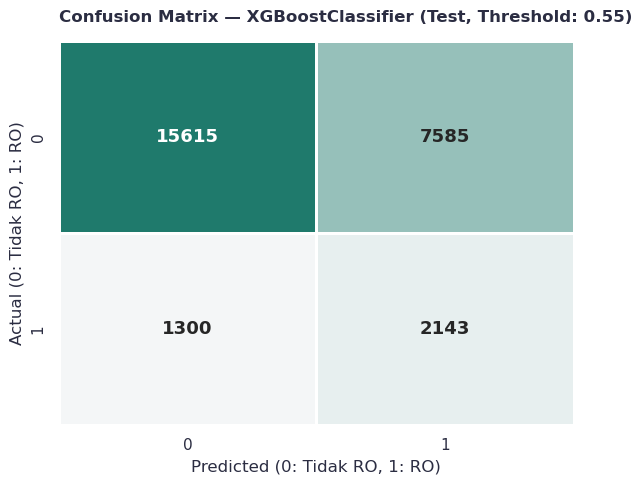

In [75]:
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list('teal_light', ['#F4F6F7', PALETTE['accent']])

cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap=custom_cmap, cbar=False, linewidths=2, linecolor='white',
            annot_kws={'fontsize': 13, 'fontweight': 'bold'}, ax=ax)
ax.set_title(f"Confusion Matrix — {best_model_name} (Test, Threshold: {final_threshold:.2f})", loc='left', fontsize=12, pad=14)
ax.set_ylabel('Actual (0: Tidak RO, 1: RO)')
ax.set_xlabel('Predicted (0: Tidak RO, 1: RO)')
plt.tight_layout()
plt.show()

**Permutation importance**

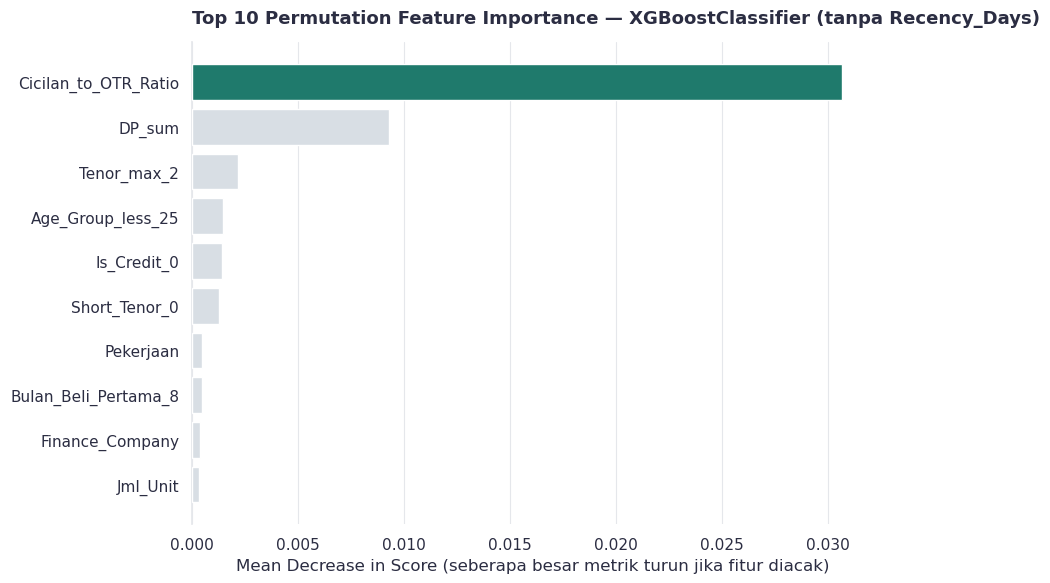

In [76]:
perm_importance = permutation_importance(
    final_model, X_test_df, y_test, n_repeats=5, random_state=42, n_jobs=-1
)
importances = perm_importance.importances_mean
indices = np.argsort(importances)[-10:]
features_ranked = [X_test_df.columns[i] for i in indices]
vals_ranked = importances[indices]
colors = [PALETTE['accent'] if v == vals_ranked.max() else PALETTE['base'] for v in vals_ranked]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(features_ranked, vals_ranked, color=colors, zorder=3)
ax.set_title(f"Top 10 Permutation Feature Importance — {best_model_name} (tanpa Recency_Days)", loc='left', fontsize=13, pad=14)
ax.set_xlabel("Mean Decrease in Score (seberapa besar metrik turun jika fitur diacak)")
style_ax(ax, grid_axis='x')
plt.tight_layout()
plt.show()

Hasil Permutation Feature Importance menunjukkan bahwa Cicilan_to_OTR_Ratio dan DP_sum merupakan prediktor paling dominan dalam memprediksi repeat order, membuktikan bahwa kapasitas finansial serta komitmen pembayaran pada transaksi pertama menjadi sinyal utama bagi tim pemasaran untuk menyasar segmen pelanggan potensial secara efisien.

**SHAP Analysis**

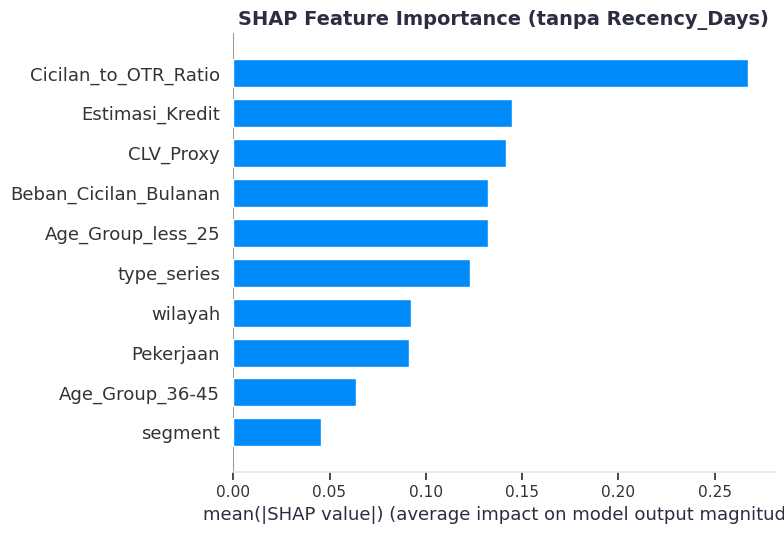

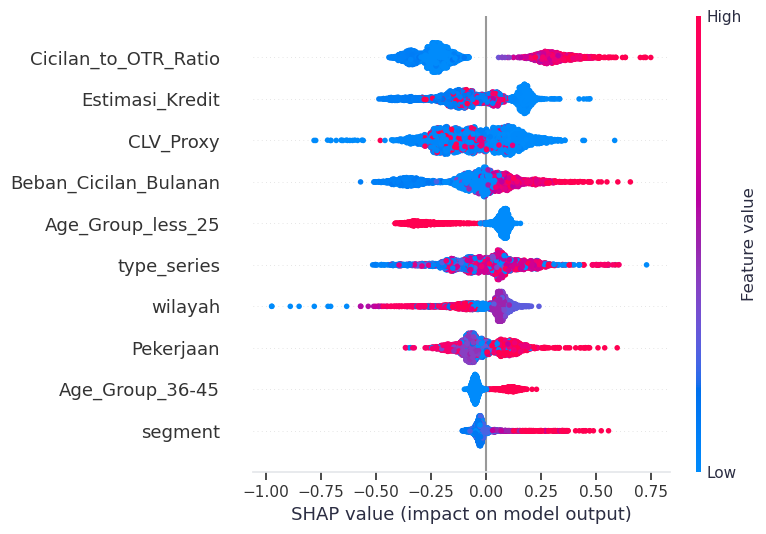

In [77]:
explainer = shap.TreeExplainer(final_model)
shap_sample = X_test_df.sample(n=3000, random_state=42)
shap_values = explainer.shap_values(shap_sample)

if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

plt.title("SHAP Feature Importance (tanpa Recency_Days)", fontsize=14, fontweight='bold')
shap.summary_plot(shap_values_plot, shap_sample, plot_type="bar", show=False, max_display=10)
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values_plot, shap_sample, show=False, max_display=10)
plt.tight_layout()
plt.show()

Cicilan_to_OTR_Ratio merupakan prediktor paling berpengaruh terhadap keputusan repeat order, di mana nilai rasio yang tinggi (titik merah di sisi kanan) mendorong peningkatan probabilitas pembelian ulang secara signifikan, didukung oleh indikator finansial seperti Estimasi_Kredit dan Beban_Cicilan_Bulanan serta variabel demografi seperti kelompok usia muda (Age_Group_less_25).

## **Lift / Gain Chart**

,n,positives,rate,pct_captured,lift
decile,,,,,
1,2665,719,0.269794,20.882951,2.087747
2,2664,612,0.229730,38.658147,1.777720
3,2664,510,0.191441,53.470810,1.481433
4,2664,426,0.159910,65.843741,1.237432
5,2664,383,0.143769,76.967761,1.112527
6,2665,287,0.107692,85.303514,0.833356
7,2664,206,0.077327,91.286669,0.598383
8,2664,155,0.058183,95.788556,0.450239
9,2664,101,0.037913,98.722045,0.293382


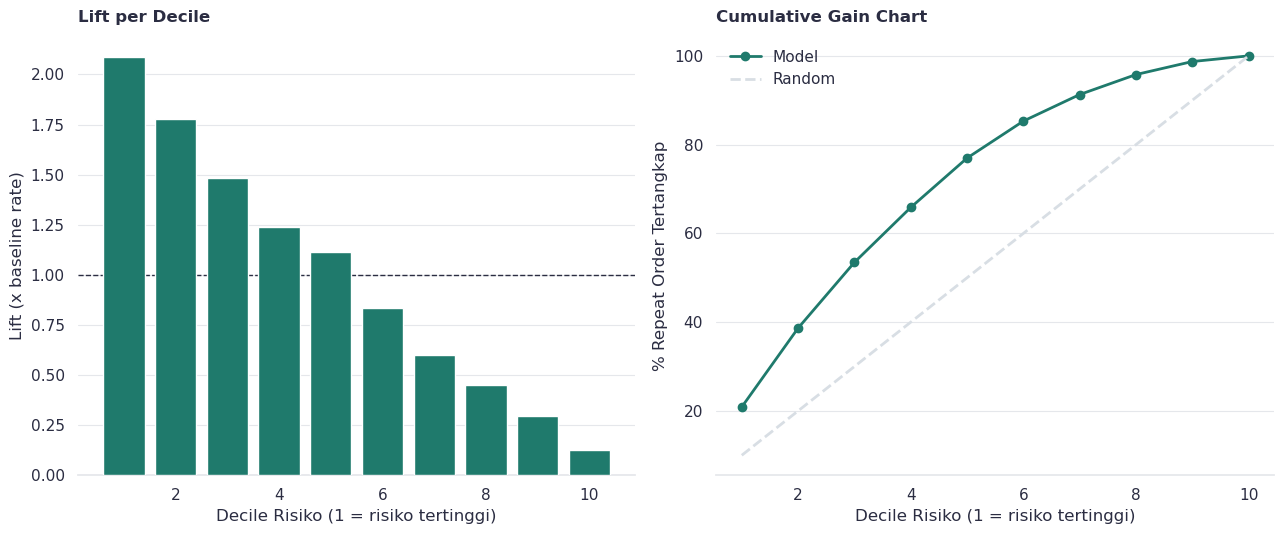

In [78]:
def lift_gain_table(y_true, y_score, n_bins=10):
    tbl = pd.DataFrame({'y': np.asarray(y_true), 'score': np.asarray(y_score)})
    tbl['decile'] = pd.qcut(tbl['score'].rank(method='first'), n_bins, labels=False)
    tbl['decile'] = n_bins - tbl['decile']  # decile 1 = skor risiko tertinggi
    g = tbl.groupby('decile').agg(n=('y', 'size'), positives=('y', 'sum')).sort_index()
    g['rate'] = g['positives'] / g['n']
    g['cum_positives'] = g['positives'].cumsum()
    total_pos = g['positives'].sum()
    g['pct_captured'] = g['cum_positives'] / total_pos * 100
    g['baseline_rate'] = total_pos / g['n'].sum()
    g['lift'] = g['rate'] / g['baseline_rate']
    return g

gain_table = lift_gain_table(y_test, y_pred_proba_final)
display(gain_table[['n', 'positives', 'rate', 'pct_captured', 'lift']])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
ax = axes[0]
ax.bar(gain_table.index, gain_table['lift'], color=PALETTE['accent'], zorder=3)
ax.axhline(1, color=PALETTE['text'], lw=1, ls='--')
ax.set_title("Lift per Decile", loc='left', fontsize=12, pad=10)
ax.set_xlabel("Decile Risiko (1 = risiko tertinggi)")
ax.set_ylabel("Lift (x baseline rate)")
style_ax(ax, grid_axis='y')

ax2 = axes[1]
ax2.plot(gain_table.index, gain_table['pct_captured'], marker='o', color=PALETTE['accent'], lw=2, label='Model')
ax2.plot([1, 10], [10, 100], color=PALETTE['base'], lw=2, ls='--', label='Random')
ax2.set_title("Cumulative Gain Chart", loc='left', fontsize=12, pad=10)
ax2.set_xlabel("Decile Risiko (1 = risiko tertinggi)")
ax2.set_ylabel("% Repeat Order Tertangkap")
ax2.legend(frameon=False)
style_ax(ax2, grid_axis='y')
plt.tight_layout()
plt.show()

Lift & Cumulative Gain Chart dihitung dengan mengurutkan pelanggan berdasarkan skor prediksi model dari yang paling potensial ke yang paling rendah, lalu membaginya ke dalam 10 kelompok sama besar (decile 1–10). Untuk tiap kelompok, Gain dihitung dari persentase akumulasi pelanggan repeat order yang berhasil tertangkap (pct_captured), sedangkan Lift mengukur berapa kali lipat efisiensi model tersebut dibanding jika kita menebak pelanggan secara acak (lift).

model memiliki efisiensi targeting yang sangat tinggi, di mana menyasar 20% pelanggan teratas (Decile 1 & 2) berhasil menangkap 38,65% dari total pelanggan yang melakukan repeat order dengan lift hingga 2,08x lipat dibanding pendekatan acak, serta mampu menjangkau lebih dari 76,96% target hanya dari 50% populasi teratas (Decile 1–5).

## **Recency Days Analysis**

In [79]:
df_final['duration'] = np.where(df_final['Target'] == 1, df_final['durasi_hari_repeat'], df_final['Recency_Days'])
df_final['event'] = df_final['Target']

# Buang baris dengan duration <= 0 (tidak valid untuk survival model)
df_surv = df_final[df_final['duration'] > 0].copy()
print(f"Baris valid untuk survival analysis: {len(df_surv):,} dari {len(df_final):,}")

Baris valid untuk survival analysis: 266,227 dari 266,422


### KaplanMeier Analysis on Recency Days

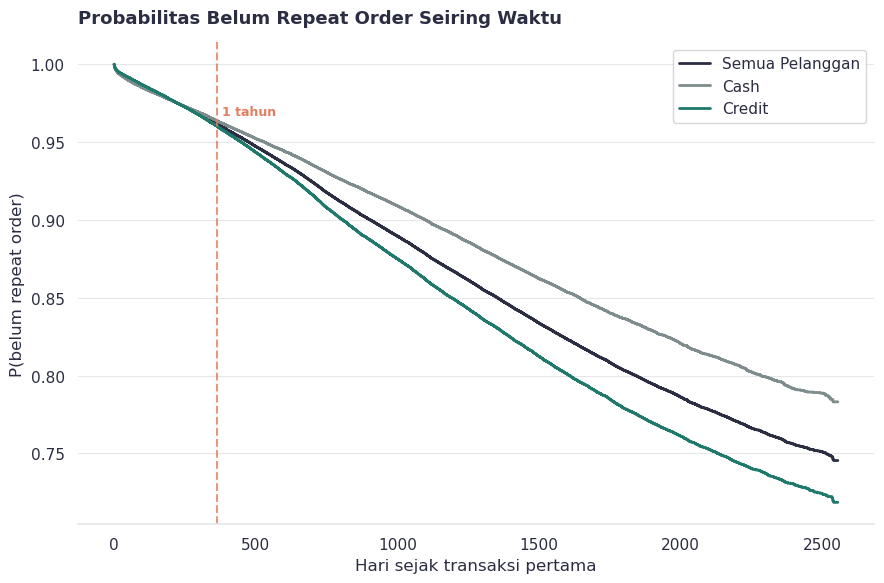

In [80]:
fig, ax = plt.subplots(figsize=(9, 6))

kmf_all = KaplanMeierFitter()
kmf_all.fit(df_surv['duration'], df_surv['event'], label='Semua Pelanggan')
kmf_all.plot_survival_function(ax=ax, color=PALETTE['text'], ci_show=False, lw=2)

for grp, color, label in [(0, '#7f8c8d', 'Cash'), (1, PALETTE['accent'], 'Credit')]:
    sub = df_surv[df_surv['Is_Credit'] == grp]
    k = KaplanMeierFitter()
    k.fit(sub['duration'], sub['event'], label=label)
    k.plot_survival_function(ax=ax, color=color, ci_show=False, lw=2)

ax.set_title("Probabilitas Belum Repeat Order Seiring Waktu", loc='left', fontsize=13, pad=14)
ax.set_xlabel("Hari sejak transaksi pertama")
ax.set_ylabel("P(belum repeat order)")
ax.axvline(365, color=PALETTE['accent2'], ls='--', lw=1.5, alpha=0.8)
ax.text(380, 0.97, '1 tahun', color=PALETTE['accent2'], fontsize=9, fontweight='bold', va='center')

style_ax(ax, grid_axis='y')
plt.tight_layout()
plt.show()

Metode Kaplan-Meier (KM) dihitung dengan melacak jejak transaksi pelanggan dari hari ke hari, lalu melihat berapa banyak pelanggan yang belum beli lagi di setiap detiknya untuk mengukur peluang retensinya secara bertahap. digunakan untuk tahu persis kapan momen paling pas (golden window) untuk menghubungi atau memberikan promo ke pelanggan.

Estimasi Kaplan-Meier dihitung dengan memetakan akumulasi durasi waktu hingga terjadinya repeat order untuk membandingkan kurva kelangsungan hidup kelompok Cash dan Credit. hasil visualisasi menunjukkan bahwa kurva mulai berpisah signifikan setelah ~500 hari di mana probabilitas belum repeat order pada pelanggan kredit turun lebih cepat, srtinya metode pembayaran kredit memiliki probabilitas pembelian ulang yang lebih tinggi dibanding metode lain seiring berjalan waktu 

### **Cox Proportional Hazards**

In [81]:
cox_num = ['Cicilan_to_OTR_Ratio', 'Beban_Cicilan_Bulanan', 'Estimasi_Kredit', 'CLV_Proxy', 'DP_Ratio', 'DP_sum', 'Jml_Unit']
cox_cat = ['Age_Group', 'Is_Credit', 'Is_NonMatic_Segment', 'Short_Tenor']

cox_df_raw = df_surv[cox_num + cox_cat + ['duration', 'event']].copy()
cox_train_raw, cox_temp_raw = train_test_split(cox_df_raw, test_size=0.4, random_state=42, stratify=cox_df_raw['event'])
cox_val_raw, cox_test_raw = train_test_split(cox_temp_raw, test_size=0.5, random_state=42, stratify=cox_temp_raw['event'])

train_medians = cox_train_raw[cox_num].median()
cox_train_raw = cox_train_raw.copy()
cox_val_raw = cox_val_raw.copy()
cox_test_raw = cox_test_raw.copy()
for col in cox_num:
    cox_train_raw[col] = cox_train_raw[col].fillna(train_medians[col])
    cox_val_raw[col] = cox_val_raw[col].fillna(train_medians[col])
    cox_test_raw[col] = cox_test_raw[col].fillna(train_medians[col])

# One-hot encode 
cox_train = pd.get_dummies(cox_train_raw, columns=cox_cat, drop_first=True)
cox_val = pd.get_dummies(cox_val_raw, columns=cox_cat, drop_first=True)
cox_test = pd.get_dummies(cox_test_raw, columns=cox_cat, drop_first=True)
cox_val = cox_val.reindex(columns=cox_train.columns, fill_value=0)
cox_test = cox_test.reindex(columns=cox_train.columns, fill_value=0)

for _df in (cox_train, cox_val, cox_test):
    bool_cols = _df.select_dtypes(bool).columns
    _df[bool_cols] = _df[bool_cols].astype(int)

print(f"Cox train: {len(cox_train):,} | val: {len(cox_val):,} | test: {len(cox_test):,}")

Cox train: 159,736 | val: 53,245 | test: 53,246


Train Set dipakai oleh model Cox PH untuk mempelajari pola data dan menghitung bobot koefisien ($\beta$) tiap fitur. Validation Set digunakan untuk pencarian nilai penalizer terbaik tanpa mengganggu data uji murni.Test Set untuk proses evaluasi model cox PH

In [82]:
# Tuning penalizer di VALIDATION set
best_pen, best_cindex, best_cph = None, -1, None
for pen in [0.0, 0.01, 0.1, 1.0]:
    cph_candidate = CoxPHFitter(penalizer=pen)
    cph_candidate.fit(cox_train, duration_col='duration', event_col='event')
    val_pred = cph_candidate.predict_partial_hazard(cox_val)
    cidx = concordance_index(cox_val['duration'], -val_pred, cox_val['event'])
    print(f"penalizer={pen}: validation C-index={cidx:.4f}")
    if cidx > best_cindex:
        best_cindex, best_pen, best_cph = cidx, pen, cph_candidate

print(f"\nPenalizer terbaik: {best_pen} (validation C-index={best_cindex:.4f})")

# Sentuh test set SATU KALI
test_pred = best_cph.predict_partial_hazard(cox_test)
test_cindex = concordance_index(cox_test['duration'], -test_pred, cox_test['event'])
print(f"Test C-index: {test_cindex:.4f}")

penalizer=0.0: validation C-index=0.5853
penalizer=0.01: validation C-index=0.5850
penalizer=0.1: validation C-index=0.5789
penalizer=1.0: validation C-index=0.5700

Penalizer terbaik: 0.0 (validation C-index=0.5853)
Test C-index: 0.5832


C-index adalah cara kita menguji ketepatan tebakan model dalam memprediksi siapa pelanggan yang akan repeat order lebih dulu. Angka 0.5832 membuktikan bahwa variabel-variabel yang digunakan (DP_Ratio, Cicilan_to_OTR, Usia, dll.) secara statistik memang membawa sinyal riil dalam memprediksi laju repeat order (lebih tinggi dibanding random chance 50%).

,coef,exp(coef),p
covariate,,,
DP_Ratio,-1.513446e-01,0.859551,1.247703e-03
DP_sum,-1.591835e-09,1.000000,2.251179e-02
CLV_Proxy,-2.483542e-10,1.000000,4.524928e-03
Estimasi_Kredit,6.025213e-10,1.000000,1.507119e-04
Beban_Cicilan_Bulanan,8.082050e-09,1.000000,1.150217e-06
Short_Tenor_1,9.534968e-02,1.100043,6.786810e-06
Is_Credit_1,2.140347e-01,1.238666,2.186137e-14
Cicilan_to_OTR_Ratio,2.635063e-01,1.301485,1.223016e-04
Age_Group_25-35,2.847935e-01,1.329488,3.332614e-43


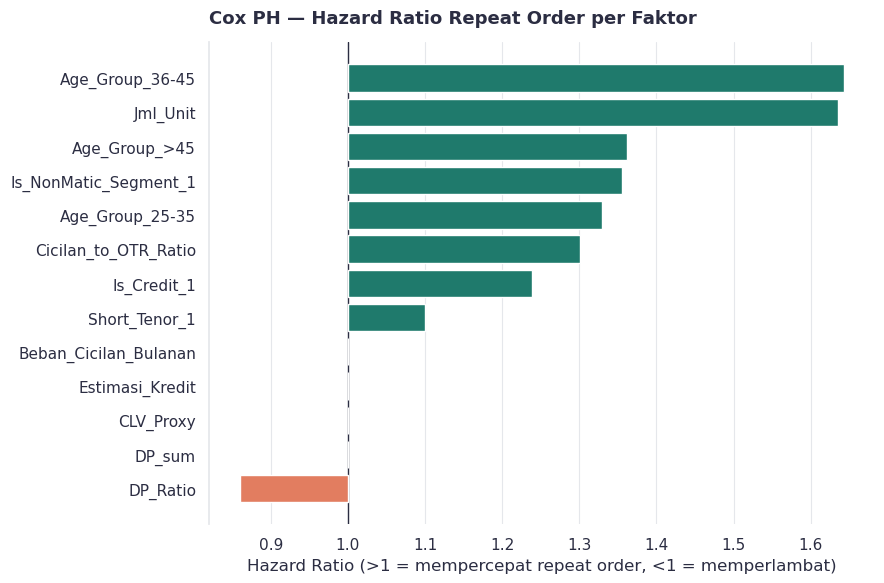

In [83]:
summ = best_cph.summary.sort_values('exp(coef)')
display(summ[['coef', 'exp(coef)', 'p']])

fig, ax = plt.subplots(figsize=(9, 6))
colors = [PALETTE['accent'] if v > 1 else PALETTE['accent2'] for v in summ['exp(coef)']]
ax.barh(summ.index, summ['exp(coef)'] - 1, left=1, color=colors, zorder=3)
ax.axvline(1, color=PALETTE['text'], lw=1)
ax.set_title("Cox PH — Hazard Ratio Repeat Order per Faktor", loc='left', fontsize=13, pad=14)
ax.set_xlabel("Hazard Ratio (>1 = mempercepat repeat order, <1 = memperlambat)")
style_ax(ax, grid_axis='x')
plt.tight_layout()
plt.show()

Pembelian ulang paling cepat didorong oleh kelompok usia 36–45 tahun dengan hazard ratio mencapai ~1,64x dibanding kelompok <25 tahun, serta didukung oleh jumlah unit yang dibeli (Jml_Unit) dan tipe kendaraan Non-Matic. Sebaliknya, DP_Ratio yang tinggi justru menjadi penahan laju repeat order. ini mungkin karena setelah mengeluarkan nominal yang cukup tinggi di awal menciptakan beban finansial lebih tinggi di depan (likuiditas pembeli terkuras), sehingga memperpanjang jeda waktu yang dibutuhkan pelanggan sebelum memutuskan untuk membeli kendaraan baru lagi.

### **Risk Scoring dari Survival Model**

In [84]:
cox_gain = lift_gain_table(cox_test['event'], test_pred)
display(cox_gain[['n', 'positives', 'rate', 'pct_captured', 'lift']])

,n,positives,rate,pct_captured,lift
decile,,,,,
1,5325,1168,0.219343,16.961952,1.696068
2,5324,932,0.175056,30.496660,1.353623
3,5325,808,0.151737,42.230613,1.173307
4,5324,899,0.168858,55.286088,1.305695
5,5325,456,0.085634,61.908220,0.662163
6,5324,674,0.126597,71.696195,0.978908
7,5325,544,0.102160,79.596282,0.789949
8,5324,559,0.104996,87.714203,0.811884
9,5325,475,0.089202,94.612257,0.689754


Tabel Decile Target ini dihitung dengan membagi test set menjadi 10 kelompok berdasarkan koefisien score dari model Cox PH untuk mengukur konsentrasi kejadian repeat order. 

Hasilnya menunjukkan bahwa Decile 1 (kelompok risiko teratas) berhasil menangkap 16,96% kejadian repeat order dengan lift 1,70x lipat dibanding pilihan acak, serta top 4 deciles (40% populasi) mampu mencakup 55,29% dari total transaksi ulang. Implikasinya, tim marketing dapat memprioritaskan alokasi anggaran retensi pada Decile 1–4 untuk memaksimalkan ROI kampanye secara efisien dibanding melakukan penjangkauan ke seluruh basis pelanggan.

### **Identifikasi Pelanggan Decile 1 (Prioritas Follow-Up)**

Setelah risk scoring membagi pelanggan ke dalam 10 decile, langkah praktis berikutnya adalah menarik **siapa saja pelanggan di Decile 1** (kelompok skor risiko tertinggi / paling cepat diprediksi repeat order) beserta profil mereka, agar bisa langsung diserahkan ke tim marketing sebagai daftar prioritas.

In [ ]:
risk = pd.DataFrame({'partial_hazard': np.asarray(test_pred).ravel()}, index=cox_test.index)
risk['decile'] = pd.qcut(risk['partial_hazard'].rank(method='first'), 10, labels=False)
risk['decile'] = 10 - risk['decile'] 

# Ambil pelanggan di Decile 1 lalu petakan ke Customer ID + profilnya
decile1_idx = risk.index[risk['decile'] == 1]
kolom_profil = ['Customer ID', 'Age_Group', 'Is_Credit', 'Short_Tenor',
                'Is_NonMatic_Segment', 'segment', 'type_series', 'Jml_Unit',
                'DP_sum', 'DP_Ratio', 'Cicilan_to_OTR_Ratio', 'CLV_Proxy',
                'wilayah', 'dealer', 'Target']
kolom_profil = [c for c in kolom_profil if c in df_final.columns]

decile1_customers = (
    df_final.loc[decile1_idx, kolom_profil]
    .join(risk.loc[decile1_idx, ['partial_hazard']])
    .sort_values('partial_hazard', ascending=False)
    .reset_index(drop=True)
)

print(f"Jumlah pelanggan di Decile 1 (test set): {len(decile1_customers):,}")
print(f"Repeat order rate di Decile 1        : {decile1_customers['Target'].mean()*100:.1f}%")
display(decile1_customers.head(20))

Jumlah pelanggan di Decile 1 (test set): 5,325
Repeat order rate di Decile 1        : 21.9%


,Customer ID,Age_Group,Is_Credit,Short_Tenor,Is_NonMatic_Segment,segment,type_series,Jml_Unit,DP_sum,DP_Ratio,Cicilan_to_OTR_Ratio,CLV_Proxy,wilayah,dealer,Target,partial_hazard
0,CUST-266679,>45,0,0,0,AT LOW,breez sport,14,0.0,0.000000,0.000000,3.990560e+09,6471,Balikpapan,1,218.981896
1,CUST-03220,36-45,0,0,0,AT LOW,breez series,12,0.0,0.000000,0.000000,2.709360e+09,6471,Balikpapan,1,131.136456
2,CUST-00023,>45,0,0,0,AT LOW,breez series,10,0.0,0.000000,0.000000,2.021800e+09,6502,Bulungan,0,47.557578
3,CUST-18735,>45,0,0,1,SPORT MID,krf150l,7,0.0,0.000000,0.000000,1.598590e+09,6405,Berau,0,16.650892
4,CUST-05177,<25,0,0,1,CUB LOW,ryvo series,7,0.0,0.000000,0.000000,1.147930e+09,6571,Tarakan,1,13.157512
5,CUST-159423,<25,0,0,1,SPORT MID,krf150l,7,0.0,0.000000,0.000000,1.762040e+09,6471,Balikpapan,1,11.909486
6,CUST-05115,>45,0,0,1,CUB MID,zyra 125 series,6,0.0,0.000000,0.000000,7.632000e+08,6471,Balikpapan,1,11.792470
7,CUST-00899,25-35,0,0,1,SPORT LOW,vexa series,6,0.0,0.000000,0.000000,8.931600e+08,6502,Bulungan,1,11.295735
8,CUST-00415,36-45,0,0,0,AT LOW,breez sport,6,0.0,0.000000,0.000000,7.387200e+08,6405,Berau,1,10.534874
9,CUST-266617,<25,1,1,1,SPORT MID,krf150l,4,146680000.0,1.000000,0.886283,5.867200e+08,6571,Tarakan,1,10.504110


Daftar di atas hanya mencakup pelanggan yang masuk **test set** (~53 ribu pelanggan, sehingga Decile 1 ~5.325 orang), karena `test_pred` memang hanya dihitung untuk test set. Untuk menghasilkan daftar prioritas atas **seluruh basis pelanggan**, model Cox digunakan untuk menskor ulang semua data seperti di bawah ini.

In [87]:
fitur_cox = cox_train.columns.drop(['duration', 'event'])

# Siapkan seluruh data survival dengan encoding yang sama seperti saat training
all_num = ['Cicilan_to_OTR_Ratio', 'Beban_Cicilan_Bulanan', 'Estimasi_Kredit',
           'CLV_Proxy', 'DP_Ratio', 'DP_sum', 'Jml_Unit']
all_cat = ['Age_Group', 'Is_Credit', 'Is_NonMatic_Segment', 'Short_Tenor']
all_raw = df_surv[all_num + all_cat].copy()
for col in all_num:
    all_raw[col] = all_raw[col].fillna(train_medians[col])  # pakai median dari TRAIN
all_enc = pd.get_dummies(all_raw, columns=all_cat, drop_first=True)
all_enc = all_enc.reindex(columns=fitur_cox, fill_value=0)
bool_cols = all_enc.select_dtypes(bool).columns
all_enc[bool_cols] = all_enc[bool_cols].astype(int)

# Skor partial hazard untuk semua pelanggan
full_pred = best_cph.predict_partial_hazard(all_enc)
risk_all = pd.DataFrame({'partial_hazard': np.asarray(full_pred).ravel()}, index=all_enc.index)
risk_all['decile'] = pd.qcut(risk_all['partial_hazard'].rank(method='first'), 10, labels=False)
risk_all['decile'] = 10 - risk_all['decile']

decile1_all_idx = risk_all.index[risk_all['decile'] == 1]
decile1_all = (
    df_final.loc[decile1_all_idx, kolom_profil]
    .join(risk_all.loc[decile1_all_idx, ['partial_hazard']])
    .sort_values('partial_hazard', ascending=False)
    .reset_index(drop=True)
)

print(f"Jumlah pelanggan di Decile 1 (seluruh basis): {len(decile1_all):,}")
print(f"Repeat order rate di Decile 1               : {decile1_all['Target'].mean()*100:.1f}%")
display(decile1_all.head(20))

Jumlah pelanggan di Decile 1 (seluruh basis): 26,623
Repeat order rate di Decile 1               : 22.7%


,Customer ID,Age_Group,Is_Credit,Short_Tenor,Is_NonMatic_Segment,segment,type_series,Jml_Unit,DP_sum,DP_Ratio,Cicilan_to_OTR_Ratio,CLV_Proxy,wilayah,dealer,Target,partial_hazard
0,CUST-00470,>45,0,0,0,AT MID,varex 125 series,20,0.0,0.000000,0.000000,1.022000e+10,6405,Berau,1,1019.570013
1,CUST-00442,25-35,0,0,0,AT LOW,breez sport,18,0.0,0.000000,0.000000,7.063200e+09,6401,Paser,0,759.632705
2,CUST-266909,<25,0,0,0,AT HIGH,pxe,19,0.0,0.000000,0.000000,1.284799e+10,6471,Balikpapan,1,263.455414
3,CUST-266907,>45,0,0,0,AT LOW,breez sport,16,0.0,0.000000,0.000000,8.184160e+09,6401,Paser,1,236.744181
4,CUST-00448,25-35,0,0,0,AT HIGH,pxe,17,0.0,0.000000,0.000000,1.047336e+10,6405,Berau,1,227.957924
5,CUST-266679,>45,0,0,0,AT LOW,breez sport,14,0.0,0.000000,0.000000,3.990560e+09,6471,Balikpapan,1,218.981896
6,CUST-266496,25-35,1,0,1,CUB LOW,ryvo series,10,37000000.0,0.236422,0.578019,1.565000e+09,6471,Balikpapan,0,182.860452
7,CUST-00002,36-45,0,0,0,AT HIGH,varex 150,13,0.0,0.000000,0.000000,4.357665e+09,6471,Balikpapan,1,152.067425
8,CUST-03220,36-45,0,0,0,AT LOW,breez series,12,0.0,0.000000,0.000000,2.709360e+09,6471,Balikpapan,1,131.136456
9,CUST-266570,25-35,0,0,1,CUB MID,zyra 125 series,11,0.0,0.000000,0.000000,2.841080e+09,6503,Tarakan,0,86.848917
